In [1]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import SpectralClustering
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random
import copy
import warnings
from tqdm import tqdm
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)               
    np.random.seed(seed)          
    torch.manual_seed(seed)        
    torch.cuda.manual_seed(seed)    
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False    

class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_dims=[100, 100], num_classes=10, 
                 dropout_p=0, activation='relu', init=True, init_method='kaiming'):
        super(MLP, self).__init__()
        self.hidden_dims = hidden_dims
        self.linear_layers = nn.ModuleList()
        layers = []

        # 1. Select activation function
        act_fn = self._get_activation(activation)
        
        # Build network structure
        current_dim = input_size
        for h_dim in hidden_dims:
            linear = nn.Linear(current_dim, h_dim)
            self.linear_layers.append(linear)
            layers.append(linear)
            layers.append(act_fn)
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            current_dim = h_dim
        
        # Output layer
        output_layer = nn.Linear(current_dim, num_classes)
        self.linear_layers.append(output_layer)
        layers.append(output_layer)
        
        self.network = nn.Sequential(*layers)
        
        # 2. Execute custom initialization
        if init:
            self._initialize_weights(init_method)
        
    def _get_activation(self, name):
        name = name.lower()
        if name == 'relu': return nn.ReLU()
        elif name == 'tanh': return nn.Tanh()
        elif name == 'sigmoid': return nn.Sigmoid()
        elif name == 'leaky_relu': return nn.LeakyReLU()
        else: return nn.ReLU()

    def _initialize_weights(self, method):
        method = method.lower()
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if method == 'kaiming':
                    init.kaiming_normal_(m.weight, nonlinearity='relu')
                elif method == 'xavier':
                    init.xavier_normal_(m.weight)
                elif method == 'orthogonal':
                    init.orthogonal_(m.weight)
                elif method == 'normal':
                    init.normal_(m.weight, mean=0, std=0.01)
                
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)
    
    def get_hidden_activations(self, x):
        """Generic method to get activations, skipping Dropout and Linear"""
        x = x.view(x.size(0), -1)
        activations = []
        for layer in self.network:
            x = layer(x)
            # Record outputs of all activation functions
            if isinstance(layer, (nn.ReLU, nn.Tanh, nn.Sigmoid, nn.LeakyReLU)):
                activations.append(x.clone())
        return activations

    def get_adjacent_weights(self):
        """
        Get weight matrices between adjacent hidden layers
        Returns: list of weight tensors with shape [out_features, in_features]
        """
        weight_matrices = []
        # Skip input and output layers, only get weights between hidden layers
        for i in range(1, len(self.linear_layers) - 1):
            weight = self.linear_layers[i].weight.data.clone()  
            weight_matrices.append(weight)
        return weight_matrices

def load_fashion_mnist(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,))
    ])
    
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, transform=transform, download=True
    )
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, transform=transform, download=True
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

def load_mnist(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, transform=transform, download=True
    )
    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, transform=transform, download=True
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

def load_cifar10(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, transform=transform, download=True
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, transform=transform, download=True
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

def train_model(model, train_loader, test_loader, epochs=5, learning_rate=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    
    train_losses = []        
    train_accuracies = []    
    test_accuracies = []     
    model_states = []        
    
    print(f"Training Start | Device: {device} | Mode: Save weights per batch, metrics per 10 batches")

    for epoch in range(epochs):
        model.train()
        
        for batch_idx, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            # Save state per batch
            state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            model_states.append(state)

            # Record metrics
            if (batch_idx + 1) % 1 == 0:
                train_losses.append(loss.item())
                _, predicted = outputs.max(1)
                acc = 100. * predicted.eq(targets).sum().item() / targets.size(0)
                train_accuracies.append(acc)

            if (batch_idx + 1) % 200 == 0:
                print(f'Epoch: {epoch+1}/{epochs} | Batch: {batch_idx+1} | Loss: {loss.item():.4f}')

        # Evaluation per Epoch
        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                _, predicted = outputs.max(1)
                test_total += targets.size(0)
                test_correct += predicted.eq(targets).sum().item()
        
        epoch_test_acc = 100. * test_correct / test_total
        test_accuracies.append(epoch_test_acc)
        print(f'>> Epoch {epoch+1} Finished | Test Acc: {epoch_test_acc:.2f}%')
        
    return train_losses, train_accuracies, test_accuracies, model_states

def plot_training_curves(train_losses, train_accuracies, test_accuracies=None, 
                         vertical_line_at=None, save_path='training_curves.png'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    epochs = range(1, len(train_losses) + 1)
    
    v_lines = []
    if vertical_line_at is not None:
        if isinstance(vertical_line_at, (int, float)):
            v_lines = [vertical_line_at]
        elif isinstance(vertical_line_at, (list, tuple)):
            v_lines = vertical_line_at
    
    ax1.plot(epochs, train_losses, 'tab:red', linewidth=2, label='Training Loss')
    for v_line in v_lines:
        ax1.axvline(x=v_line, color='black', linestyle='--', linewidth=2, label=f'Step {v_line}')
    ax1.set_title('Training Loss Over Time', fontsize=14)
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    ax2.plot(epochs, train_accuracies, 'tab:purple', linewidth=2, label='Training Accuracy')
    if test_accuracies is not None:
        ax2.plot(epochs, test_accuracies, 'r-', linewidth=2, label='Test Accuracy')
    for v_line in v_lines:
        ax2.axvline(x=v_line, color='black', linestyle='--', linewidth=2, label=f'Step {v_line}')
    ax2.set_title('Training and Test Accuracy Over Time', fontsize=14)
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def get_functional_connectivity(model, data_loader, samples_per_class=1000):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    class_samples = {i: [] for i in range(10)}
    with torch.no_grad():
        for data, targets in data_loader:
            data, targets = data.to(device), targets.to(device)
            for i in range(len(targets)):
                class_label = targets[i].item()
                if len(class_samples[class_label]) < samples_per_class:
                    class_samples[class_label].append(data[i])
            if all(len(samples) >= samples_per_class for samples in class_samples.values()):
                break
    
    all_samples = []
    for class_label in range(10):
        all_samples.extend(class_samples[class_label][:samples_per_class])
    
    all_samples = torch.stack(all_samples).to(device)
    all_activations = []
    batch_size = 256
    
    with torch.no_grad():
        for i in range(0, len(all_samples), batch_size):
            batch = all_samples[i:i+batch_size]
            activations = model.get_hidden_activations(batch) 
            batch_concat = torch.cat(activations, dim=1)
            all_activations.append(batch_concat)
    
    Activation_Matrix = torch.cat(all_activations, dim=0).cpu().numpy()    
    FC_Original = np.corrcoef(Activation_Matrix.T)
    FC_Original = np.nan_to_num(FC_Original)
    
    return FC_Original

def train(act='tanh', init=True, init_method='orthogonal'):
    set_seed(42) 
    model = MLP(input_size=input_size, hidden_dims=hidden_dims, activation=act, init=init, init_method=init_method)
    print(f"Model architecture: {model}")
    train_losses, train_accuracies, test_accuracies, models = train_model(
        model, train_loader, test_loader, epochs=epochs, learning_rate=learning_rate
    )
    return train_losses, train_accuracies, test_accuracies, models

def analyze_connectivity_evolution(models, act='tanh', init_method='orthogonal', step_interval=10):    
    template_model = MLP(input_size=input_size, hidden_dims=hidden_dims)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    template_model.to(device)
    
    sampled_steps = []
    scc_max_values = []
    fc_max_values = []
    corr_values = []
    stats = {
        'prop_gt_095': [], 'prop_gt_09': [], 'prop_gt_08': [], 'prop_gt_07': [], 'prop_gt_075': [], 'prop_gt_06': [],
        'is_prop_gt_095': [], 'is_prop_gt_09': [], 'is_prop_gt_08': [], 'is_prop_gt_07': [], 'is_prop_gt_075': [], 'is_prop_gt_06': []
    }

    print("Extracting metrics and aligning data...")

    for i in tqdm(range(0, len(models), step_interval)):
        template_model.load_state_dict(models[i])
        template_model.eval()
        
        with torch.no_grad():
            # IS
            weights = template_model.linear_layers[1].weight.detach().cpu().numpy()
            current_is = np.corrcoef(weights)
            is_triu = current_is[np.triu_indices(100, k=1)]
            
            # FC
            FC = get_functional_connectivity(template_model, train_loader, samples_per_class=100)
            fc_all_triu = FC[np.triu_indices(100, k=1)]
            
            total_pairs = len(fc_all_triu)
            stats['prop_gt_095'].append(np.sum(fc_all_triu > 0.95) / total_pairs * 100)
            stats['prop_gt_09'].append(np.sum(fc_all_triu > 0.9) / total_pairs * 100) 
            stats['prop_gt_08'].append(np.sum(fc_all_triu > 0.8) / total_pairs * 100)
            stats['prop_gt_07'].append(np.sum(fc_all_triu > 0.7) / total_pairs * 100)
            stats['prop_gt_075'].append(np.sum(fc_all_triu > 0.75) / total_pairs * 100)
            stats['prop_gt_06'].append(np.sum(fc_all_triu > 0.6) / total_pairs * 100)

            stats['is_prop_gt_095'].append(np.sum(is_triu > 0.95) / total_pairs * 100)
            stats['is_prop_gt_09'].append(np.sum(is_triu > 0.9) / total_pairs * 100)
            stats['is_prop_gt_08'].append(np.sum(is_triu > 0.8) / total_pairs * 100)
            stats['is_prop_gt_07'].append(np.sum(is_triu > 0.7) / total_pairs * 100)
            stats['is_prop_gt_075'].append(np.sum(is_triu > 0.75) / total_pairs * 100)
            stats['is_prop_gt_06'].append(np.sum(is_triu > 0.6) / total_pairs * 100)
            
            fc_sub = FC[100:200, 100:200]
            fc_triu = fc_sub[np.triu_indices(100, k=1)]
            sampled_steps.append(i)
            scc_max_values.append(np.max(is_triu))
            fc_max_values.append(np.max(fc_triu))
            
            if np.any(is_triu) and np.any(fc_triu):
                c = np.corrcoef(is_triu, fc_triu)[0, 1]
                corr_values.append(np.nan_to_num(c))
            else:
                corr_values.append(0)

    plt.figure(figsize=(8, 5))
    plt.plot(sampled_steps, scc_max_values, label='Input similarity(IS)', linewidth=2)
    plt.plot(sampled_steps, fc_max_values, label='Functional connectivity(FC)', linewidth=2)
    plt.plot(sampled_steps, corr_values, label='IS-FC Pearson Corr', linewidth=2)

    plt.xlabel('Training Steps', fontsize=12, fontweight='bold')
    plt.ylabel('Pearson Correlation', fontsize=12, fontweight='bold')
    plt.title('FC-IS dynamic evolution', fontsize=14, fontweight='bold')
    plt.legend(prop={'weight': 'bold', 'size': 12})
    plt.show()
    return sampled_steps, scc_max_values, fc_max_values, corr_values, stats 

Building MLP with hidden dimensions: [100, 100]
Model architecture: MLP(
  (linear_layers): ModuleList(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): Linear(in_features=100, out_features=100, bias=True)
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
  (network): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)
Training Start | Device: cuda | Mode: Save weights per batch, metrics per 10 batches
Epoch: 1/5 | Batch: 200 | Loss: 2.1580
>> Epoch 1 Finished | Test Acc: 33.47%
Epoch: 2/5 | Batch: 200 | Loss: 0.6908
>> Epoch 2 Finished | Test Acc: 84.08%
Epoch: 3/5 | Batch: 200 | Loss: 0.2870
>> Epoch 3 Finished | Test Acc: 89.65%
Epoch: 4/5 | Batch: 200 | Loss: 0.2911
>> Epoch 4 Finished | Test Acc: 91.39%
Epoch: 5/5 | Batch: 200 | Loss: 0.2743
>> Epoch 5 Finished | T

100%|██████████| 1175/1175 [08:09<00:00,  2.40it/s]


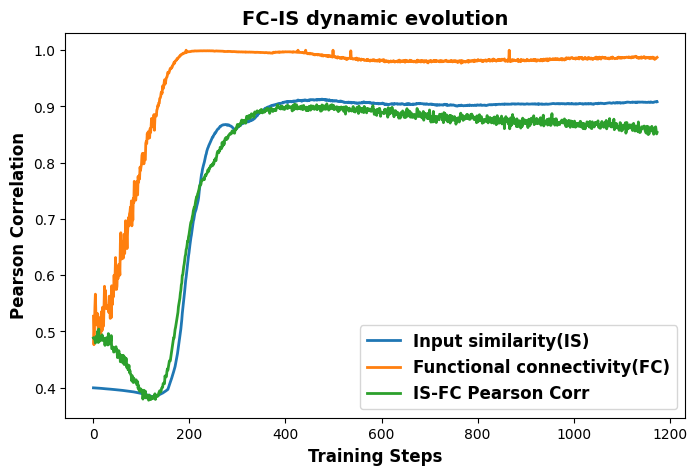

In [2]:
act = 'relu'
init_method = 'normal'
set_seed(42) 
hidden_dims = [100, 100]  # You can change this to [256, 128] or any other configuration
dropout_p = 0.3
epochs = 5
batch_size = 256
learning_rate = 0.05
data = 'MNIST'    # MNIST or FashionMNIST or cifar10

print(f"Building MLP with hidden dimensions: {hidden_dims}")

# Load data
input_size=784
if data == 'FashionMNIST':
    train_loader, test_loader = load_fashion_mnist(batch_size=batch_size)
elif data == 'MNIST':
    train_loader, test_loader = load_mnist(batch_size=batch_size)
elif data == 'cifar10':
    train_loader, test_loader = load_cifar10(batch_size=batch_size)
    input_size=3072

train_losses, train_accuracies, test_accuracies, models = train(act=act, init=True, init_method=init_method)
sampled_steps, scc_max_values, fc_max_values, corr_values, fc_is_proportion = analyze_connectivity_evolution(models, act=act, init_method=init_method, step_interval=1)

Extracting FC trajectories...


100%|██████████| 1175/1175 [08:11<00:00,  2.39it/s]



FC rising pair classification
Total pairs: 4950
Rising pairs: 1256
Early pairs: 628
Late pairs: 628
Median rise time: 183.0
Pairs tied at median: 14
Median-tied pairs assigned to early: 11
Median-tied pairs assigned to late: 3
Rise time min mean median max: 102 183.27707006369425 183.0 260

Top timing neuron selection
Valid neurons: 76
Early-like neurons: 15 [78, 4, 62, 56, 61, 72, 91, 29, 40, 21, 23, 76, 80, 81, 83]
Late-like neurons: 15 [65, 20, 7, 33, 30, 35, 37, 96, 16, 79, 19, 77, 36, 49, 46]
Mean early ratio
Early-like: 0.8060526313745817
Late-like: 0.0
Mean late ratio
Early-like: 0.19394736837197687
Late-like: 0.9999999994236418


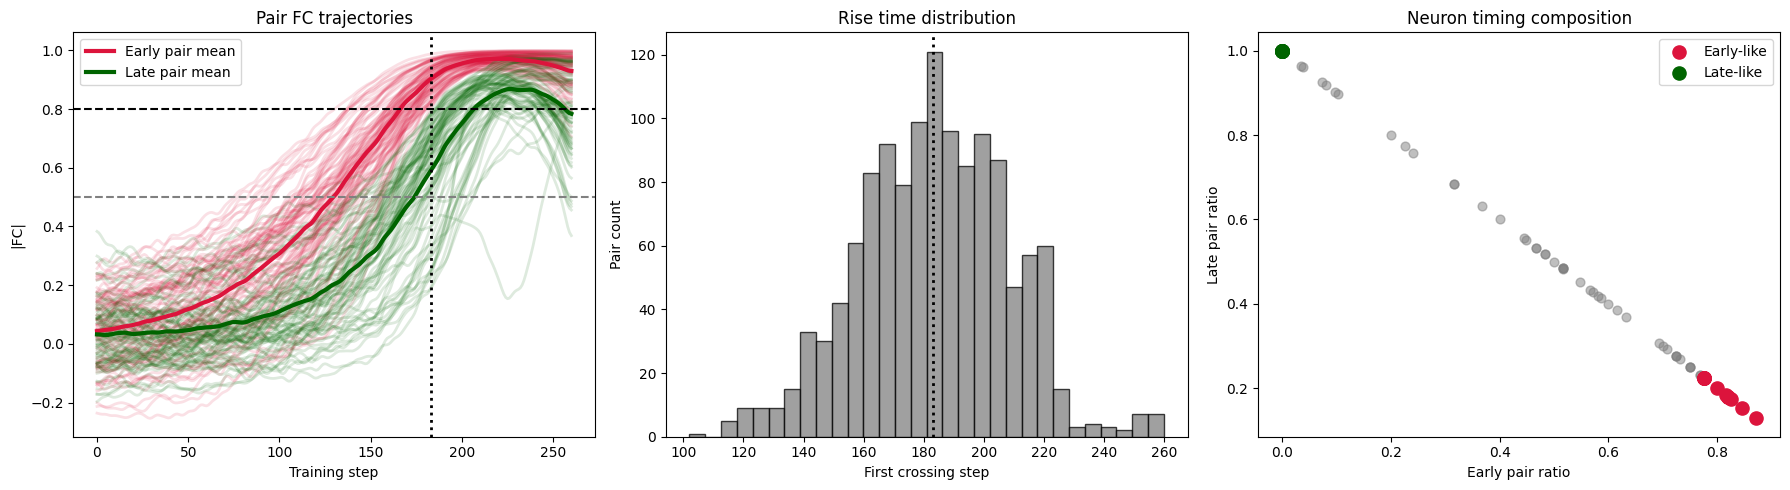

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def extract_fc_trajectories(models, data_loader, input_size, hidden_dims, num_classes=10, act="relu", step_interval=1, layer_idx=1, samples_per_class=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    template_model = MLP(input_size=input_size, hidden_dims=hidden_dims, num_classes=num_classes, activation=act, init=False).to(device)
    start = sum(hidden_dims[:layer_idx])
    end = start + hidden_dims[layer_idx]
    fc_abs, fc_raw, sampled_steps = [], [], []
    print("Extracting FC trajectories...")
    for step in tqdm(range(0, len(models), step_interval)):
        template_model.load_state_dict(models[step])
        template_model.eval()
        FC = get_functional_connectivity(template_model, data_loader, samples_per_class=samples_per_class)
        fc_sub = FC[start:end, start:end]
        fc_abs.append(np.abs(fc_sub))
        fc_raw.append(fc_sub)
        sampled_steps.append(step)
    return np.stack(fc_abs), np.stack(fc_raw), np.array(sampled_steps)

def get_window_indices(sampled_steps, window):
    idx = np.where((sampled_steps >= window[0]) & (sampled_steps <= window[1]))[0]
    if len(idx) == 0:
        raise ValueError(f"No sampled steps found in window {window}")
    return idx

# def classify_rising_pairs_by_median_time(fc_trajectories_abs, sampled_steps, low_thres=0.5, high_thres=0.8, pre_window=(0, 20), rise_window=(20, 260), smooth_sigma=2.0, min_rise_amplitude=0.3):
#     n = fc_trajectories_abs.shape[1]
#     pre_idx = get_window_indices(sampled_steps, pre_window)
#     rise_idx = get_window_indices(sampled_steps, rise_window)
#     fc_smooth = gaussian_filter1d(fc_trajectories_abs, sigma=smooth_sigma, axis=0)
#     rising_pairs, rise_times, peak_values, pre_values = [], [], [], []
#     for i in range(n):
#         for j in range(i + 1, n):
#             pre_mean = fc_smooth[pre_idx, i, j].mean()
#             traj = fc_smooth[rise_idx, i, j]
#             peak = traj.max()
#             if pre_mean >= low_thres:
#                 continue
#             if peak < high_thres:
#                 continue
#             if peak - pre_mean < min_rise_amplitude:
#                 continue
#             cross = np.where(traj >= high_thres)[0]
#             if len(cross) == 0:
#                 continue
#             t_cross = sampled_steps[rise_idx[cross[0]]]
#             rising_pairs.append((i, j))
#             rise_times.append(t_cross)
#             peak_values.append(peak)
#             pre_values.append(pre_mean)
#     rise_times = np.array(rise_times)
#     peak_values = np.array(peak_values)
#     pre_values = np.array(pre_values)
#     if len(rising_pairs) == 0:
#         raise ValueError("No rising pairs found. Try lower high_thres or wider rise_window.")
#     median_time = np.median(rise_times)
#     early_pairs = [p for p, t in zip(rising_pairs, rise_times) if t <= median_time]
#     late_pairs = [p for p, t in zip(rising_pairs, rise_times) if t > median_time]
#     print("")
#     print("FC rising pair classification")
#     print("Total pairs:", n * (n - 1) // 2)
#     print("Rising pairs:", len(rising_pairs))
#     print("Early pairs:", len(early_pairs))
#     print("Late pairs:", len(late_pairs))
#     print("Rise time min mean median max:", rise_times.min(), rise_times.mean(), median_time, rise_times.max())
#     return {"rising_pairs": rising_pairs, "early_rise_pairs": early_pairs, "late_rise_pairs": late_pairs, "rise_times": rise_times, "peak_values": peak_values, "pre_values": pre_values, "median_time": median_time, "low_thres": low_thres, "high_thres": high_thres, "pre_window": pre_window, "rise_window": rise_window}

def classify_rising_pairs_by_median_time(fc_trajectories_abs, sampled_steps, low_thres=0.5, high_thres=0.8, pre_window=(0, 20), rise_window=(20, 260), smooth_sigma=2.0, min_rise_amplitude=0.3):
    n = fc_trajectories_abs.shape[1]
    pre_idx = get_window_indices(sampled_steps, pre_window)
    rise_idx = get_window_indices(sampled_steps, rise_window)
    fc_smooth = gaussian_filter1d(fc_trajectories_abs, sigma=smooth_sigma, axis=0)
    rising_pairs, rise_times, rise_slopes = [], [], []
    peak_times, peak_values, pre_values, rise_amplitudes = [], [], [], []

    for i in range(n):
        for j in range(i + 1, n):
            pre_mean = fc_smooth[pre_idx, i, j].mean()
            traj = fc_smooth[rise_idx, i, j]
            peak = traj.max()
            if pre_mean >= low_thres or peak < high_thres or peak - pre_mean < min_rise_amplitude:
                continue

            cross = np.where(traj >= high_thres)[0]
            if len(cross) == 0:
                continue

            cross_local_idx = int(cross[0])
            cross_global_idx = int(rise_idx[cross_local_idx])
            t_cross = sampled_steps[cross_global_idx]

            if cross_global_idx > 0:
                previous_idx = cross_global_idx - 1
                dt = sampled_steps[cross_global_idx] - sampled_steps[previous_idx]
                slope = (fc_smooth[cross_global_idx, i, j] - fc_smooth[previous_idx, i, j]) / dt if dt > 0 else 0.0
            elif len(sampled_steps) > 1:
                dt = sampled_steps[1] - sampled_steps[0]
                slope = (fc_smooth[1, i, j] - fc_smooth[0, i, j]) / dt if dt > 0 else 0.0
            else:
                slope = 0.0

            peak_local_idx = int(np.argmax(traj))
            peak_time = sampled_steps[rise_idx[peak_local_idx]]
            rising_pairs.append((i, j))
            rise_times.append(t_cross)
            rise_slopes.append(slope)
            peak_times.append(peak_time)
            peak_values.append(peak)
            pre_values.append(pre_mean)
            rise_amplitudes.append(peak - pre_mean)

    if len(rising_pairs) == 0:
        raise ValueError("No rising pairs found. Try lower high_thres or wider rise_window.")

    rise_times = np.asarray(rise_times)
    rise_slopes = np.asarray(rise_slopes)
    peak_times = np.asarray(peak_times)
    peak_values = np.asarray(peak_values)
    pre_values = np.asarray(pre_values)
    rise_amplitudes = np.asarray(rise_amplitudes)
    median_time = np.median(rise_times)

    tied_mask = np.isclose(rise_times, median_time, rtol=0.0, atol=1e-12)
    early_indices = np.where((rise_times < median_time) & ~tied_mask)[0].tolist()
    late_indices = np.where((rise_times > median_time) & ~tied_mask)[0].tolist()
    tied_indices = np.where(tied_mask)[0].tolist()

    tied_indices = sorted(tied_indices, key=lambda k: (
        -rise_slopes[k],
        peak_times[k],
        -peak_values[k],
        -rise_amplitudes[k],
        rising_pairs[k][0],
        rising_pairs[k][1]
    ))

    target_early_count = (len(rising_pairs) + 1) // 2
    n_tied_to_early = target_early_count - len(early_indices)
    n_tied_to_early = max(0, min(n_tied_to_early, len(tied_indices)))
    early_indices.extend(tied_indices[:n_tied_to_early])
    late_indices.extend(tied_indices[n_tied_to_early:])

    full_sort_key = lambda k: (
        rise_times[k],
        -rise_slopes[k],
        peak_times[k],
        -peak_values[k],
        -rise_amplitudes[k],
        rising_pairs[k][0],
        rising_pairs[k][1]
    )
    early_indices = sorted(early_indices, key=full_sort_key)
    late_indices = sorted(late_indices, key=full_sort_key)
    early_pairs = [rising_pairs[k] for k in early_indices]
    late_pairs = [rising_pairs[k] for k in late_indices]

    print("")
    print("FC rising pair classification")
    print("Total pairs:", n * (n - 1) // 2)
    print("Rising pairs:", len(rising_pairs))
    print("Early pairs:", len(early_pairs))
    print("Late pairs:", len(late_pairs))
    print("Median rise time:", median_time)
    print("Pairs tied at median:", len(tied_indices))
    print("Median-tied pairs assigned to early:", n_tied_to_early)
    print("Median-tied pairs assigned to late:", len(tied_indices) - n_tied_to_early)
    print("Rise time min mean median max:", rise_times.min(), rise_times.mean(), median_time, rise_times.max())

    return {
        "rising_pairs": rising_pairs,
        "early_rise_pairs": early_pairs,
        "late_rise_pairs": late_pairs,
        "rise_times": rise_times,
        "rise_slopes": rise_slopes,
        "peak_times": peak_times,
        "peak_values": peak_values,
        "pre_values": pre_values,
        "rise_amplitudes": rise_amplitudes,
        "early_indices": np.asarray(early_indices),
        "late_indices": np.asarray(late_indices),
        "median_time": median_time,
        "low_thres": low_thres,
        "high_thres": high_thres,
        "pre_window": pre_window,
        "rise_window": rise_window
    }

def select_top_timing_neurons(early_pairs, late_pairs, hidden_size=100, n_select=15, min_total_pairs=5):
    early_count = np.zeros(hidden_size)
    late_count = np.zeros(hidden_size)
    total_count = np.zeros(hidden_size)
    for i, j in early_pairs:
        early_count[i] += 1
        early_count[j] += 1
        total_count[i] += 1
        total_count[j] += 1
    for i, j in late_pairs:
        late_count[i] += 1
        late_count[j] += 1
        total_count[i] += 1
        total_count[j] += 1
    early_ratio = early_count / (total_count + 1e-8)
    late_ratio = late_count / (total_count + 1e-8)
    timing_bias = early_ratio - late_ratio
    valid = np.where(total_count >= min_total_pairs)[0]
    early_order = sorted(valid.tolist(), key=lambda x: (timing_bias[x], total_count[x]), reverse=True)
    late_order = sorted(valid.tolist(), key=lambda x: (timing_bias[x], -total_count[x]))
    early_idx = np.array(early_order[:n_select], dtype=int)
    late_idx = []
    early_set = set(early_idx.tolist())
    for n in late_order:
        if n not in early_set:
            late_idx.append(n)
        if len(late_idx) == n_select:
            break
    late_idx = np.array(late_idx, dtype=int)
    print("")
    print("Top timing neuron selection")
    print("Valid neurons:", len(valid))
    print("Early-like neurons:", len(early_idx), early_idx.tolist())
    print("Late-like neurons:", len(late_idx), late_idx.tolist())
    print("Mean early ratio")
    print("Early-like:", early_ratio[early_idx].mean())
    print("Late-like:", early_ratio[late_idx].mean())
    print("Mean late ratio")
    print("Early-like:", late_ratio[early_idx].mean())
    print("Late-like:", late_ratio[late_idx].mean())
    return {"early_idx": early_idx, "late_idx": late_idx, "early_count": early_count, "late_count": late_count, "total_count": total_count, "early_ratio": early_ratio, "late_ratio": late_ratio, "timing_bias": timing_bias, "valid": valid}

def plot_fc_timing_trajectory_summary(fc_trajectories_abs, sampled_steps, rise_result, neuron_result, display_max_step=260, sigma=2.0, num_pairs=80, seed=42):
    rng = np.random.default_rng(seed)
    keep = sampled_steps <= display_max_step
    s_steps = sampled_steps[keep]
    s_fc = fc_trajectories_abs[keep]
    early_pairs = rise_result["early_rise_pairs"]
    late_pairs = rise_result["late_rise_pairs"]
    early_idx = neuron_result["early_idx"]
    late_idx = neuron_result["late_idx"]
    early_ratio = neuron_result["early_ratio"]
    late_ratio = neuron_result["late_ratio"]
    valid = neuron_result["valid"]
    def sample_pairs(pairs):
        if len(pairs) <= num_pairs:
            return pairs
        idx = rng.choice(len(pairs), size=num_pairs, replace=False)
        return [pairs[i] for i in idx]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    early_trajs, late_trajs = [], []
    for i, j in sample_pairs(early_pairs):
        traj = gaussian_filter1d(s_fc[:, i, j], sigma=sigma)
        early_trajs.append(traj)
        axes[0].plot(s_steps, traj, color="crimson", alpha=0.13, linewidth=2)
    for i, j in sample_pairs(late_pairs):
        traj = gaussian_filter1d(s_fc[:, i, j], sigma=sigma)
        late_trajs.append(traj)
        axes[0].plot(s_steps, traj, color="darkgreen", alpha=0.13, linewidth=2)
    axes[0].plot(s_steps, np.mean(early_trajs, axis=0), color="crimson", linewidth=3, label="Early pair mean")
    axes[0].plot(s_steps, np.mean(late_trajs, axis=0), color="darkgreen", linewidth=3, label="Late pair mean")
    axes[0].axhline(rise_result["low_thres"], color="gray", linestyle="--")
    axes[0].axhline(rise_result["high_thres"], color="black", linestyle="--")
    axes[0].axvline(rise_result["median_time"], color="black", linestyle=":", linewidth=2)
    axes[0].set_title("Pair FC trajectories")
    axes[0].set_xlabel("Training step")
    axes[0].set_ylabel("|FC|")
    axes[0].legend()
    axes[1].hist(rise_result["rise_times"], bins=30, color="gray", alpha=0.75, edgecolor="black")
    axes[1].axvline(rise_result["median_time"], color="black", linestyle=":", linewidth=2)
    axes[1].set_title("Rise time distribution")
    axes[1].set_xlabel("First crossing step")
    axes[1].set_ylabel("Pair count")
    axes[2].scatter(early_ratio[valid], late_ratio[valid], c="gray", s=40, alpha=0.5)
    axes[2].scatter(early_ratio[early_idx], late_ratio[early_idx], c="crimson", s=90, label="Early-like")
    axes[2].scatter(early_ratio[late_idx], late_ratio[late_idx], c="darkgreen", s=90, label="Late-like")
    axes[2].set_xlabel("Early pair ratio")
    axes[2].set_ylabel("Late pair ratio")
    axes[2].set_title("Neuron timing composition")
    axes[2].legend()
    plt.tight_layout()
    plt.show()

def build_checkpoint_model(models, model_step, input_size, hidden_dims, num_classes=10, act="relu"):
    if model_step == "last":
        idx = len(models) - 1
        label = "last"
    else:
        idx = int(model_step)
        label = str(model_step)
    if idx < 0 or idx >= len(models):
        raise ValueError(f"Requested model step {model_step} is outside models length {len(models)}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLP(input_size=input_size, hidden_dims=hidden_dims, num_classes=num_classes, activation=act, init=False).to(device)
    model.load_state_dict(models[idx])
    model.eval()
    return model, idx, label

def evaluate_acc_loss(model, data_loader):
    model.eval()
    device = next(model.parameters()).device
    criterion = nn.CrossEntropyLoss()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for data, targets in data_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            loss = criterion(outputs, targets)
            pred = outputs.argmax(dim=1)
            correct += (pred == targets).sum().item()
            total += targets.size(0)
            loss_sum += loss.item() * targets.size(0)
    return 100.0 * correct / total, loss_sum / total

def make_output_lesioned_model(model, layer_index, lesion_nodes):
    m = copy.deepcopy(model)
    m.eval()
    with torch.no_grad():
        if len(lesion_nodes) > 0:
            m.linear_layers[layer_index + 1].weight[:, lesion_nodes] = 0.0
    return m

def run_fc_timing_ablation(model, test_loader, early_nodes, late_nodes, layer_index=1, hidden_size=100, k=10, repeat=100, seed=42, step_label=""):
    rng = np.random.default_rng(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    early_nodes = sorted([int(x) for x in early_nodes])
    late_nodes = sorted([int(x) for x in late_nodes])
    all_nodes = set(range(hidden_size))
    random_pool = sorted(list(all_nodes - set(early_nodes) - set(late_nodes)))
    if k > min(len(early_nodes), len(late_nodes)):
        k = min(len(early_nodes), len(late_nodes))
        print("k reduced to", k)
    baseline_acc, baseline_loss = evaluate_acc_loss(model, test_loader)
    print("")
    print("FC timing ablation setup")
    print("Model step:", step_label)
    print("Baseline accuracy:", baseline_acc)
    print("Baseline loss:", baseline_loss)
    print("Early nodes:", len(early_nodes), early_nodes)
    print("Late nodes:", len(late_nodes), late_nodes)
    print("Random other pool:", len(random_pool))
    print("k:", k, "repeat:", repeat)
    records = []
    for r in range(repeat):
        e_nodes = rng.choice(early_nodes, size=k, replace=False).astype(int).tolist()
        l_nodes = rng.choice(late_nodes, size=k, replace=False).astype(int).tolist()
        rand_nodes = rng.choice(random_pool, size=k, replace=False).astype(int).tolist()
        e_model = make_output_lesioned_model(model, layer_index, e_nodes).to(device)
        l_model = make_output_lesioned_model(model, layer_index, l_nodes).to(device)
        r_model = make_output_lesioned_model(model, layer_index, rand_nodes).to(device)
        e_acc, e_loss = evaluate_acc_loss(e_model, test_loader)
        l_acc, l_loss = evaluate_acc_loss(l_model, test_loader)
        r_acc, r_loss = evaluate_acc_loss(r_model, test_loader)
        records.append({"Step": step_label, "Repeat": r, "Group": "Early FC-rise", "Accuracy": e_acc, "Loss": e_loss, "Acc_Change": e_acc - baseline_acc, "Loss_Change": e_loss - baseline_loss, "Lesion_Nodes": e_nodes})
        records.append({"Step": step_label, "Repeat": r, "Group": "Late FC-rise", "Accuracy": l_acc, "Loss": l_loss, "Acc_Change": l_acc - baseline_acc, "Loss_Change": l_loss - baseline_loss, "Lesion_Nodes": l_nodes})
        records.append({"Step": step_label, "Repeat": r, "Group": "Random other", "Accuracy": r_acc, "Loss": r_loss, "Acc_Change": r_acc - baseline_acc, "Loss_Change": r_loss - baseline_loss, "Lesion_Nodes": rand_nodes})
    df = pd.DataFrame(records)
    print("")
    print("Ablation summary")
    print(df.groupby("Group")["Acc_Change"].agg(["mean", "std", "count"]).to_string())
    print("")
    print("Welch t-tests")
    groups = ["Early FC-rise", "Late FC-rise", "Random other"]
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            x = df[df["Group"] == groups[i]]["Acc_Change"].values
            y = df[df["Group"] == groups[j]]["Acc_Change"].values
            t, p = ttest_ind(x, y, equal_var=False)
            print(f"{groups[i]} vs {groups[j]}: t={t:.4f}, p={p:.4e}")
    plt.figure(figsize=(6, 5))
    sns.barplot(data=df, x="Group", y="Acc_Change", order=groups, palette=["crimson", "darkgreen", "gray"], errorbar="sd", alpha=0.65)
    sns.stripplot(data=df, x="Group", y="Acc_Change", order=groups, color="black", alpha=0.45, jitter=0.18, size=4)
    plt.axhline(0, color="black", linestyle="--")
    plt.ylabel("Accuracy change vs step baseline")
    plt.xlabel("")
    plt.title(f"FC timing neuron ablation, step={step_label}, k={k}")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
    return df, {"baseline_acc": baseline_acc, "baseline_loss": baseline_loss, "k": k, "random_pool": random_pool}

def collect_fc_timing_lost_samples(model, data_loader, early_nodes, late_nodes, layer_index=1, step_label=""):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    early_model = make_output_lesioned_model(model, layer_index, early_nodes).to(device)
    late_model = make_output_lesioned_model(model, layer_index, late_nodes).to(device)
    reps, records = [], []
    with torch.no_grad():
        sample_idx = 0
        for data, targets in data_loader:
            data, targets = data.to(device), targets.to(device)
            base_logits = model(data)
            early_logits = early_model(data)
            late_logits = late_model(data)
            base_probs = F.softmax(base_logits, dim=1)
            base_pred = base_logits.argmax(dim=1)
            early_pred = early_logits.argmax(dim=1)
            late_pred = late_logits.argmax(dim=1)
            sorted_probs, _ = torch.sort(base_probs, dim=1, descending=True)
            sorted_logits, _ = torch.sort(base_logits, dim=1, descending=True)
            prob_margin = sorted_probs[:, 0] - sorted_probs[:, 1]
            logit_margin = sorted_logits[:, 0] - sorted_logits[:, 1]
            true_probs = base_probs.gather(1, targets[:, None]).squeeze(1)
            acts = model.get_hidden_activations(data)[layer_index].detach().cpu().numpy()
            entropy = -torch.sum(base_probs * torch.log(base_probs + 1e-9), dim=1)
            msp, _ = torch.max(base_probs, dim=1)
            energy = -torch.logsumexp(base_logits, dim=1)
            for i in range(data.size(0)):
                y = targets[i].item()
                b = base_pred[i].item()
                if b != y:
                    sample_idx += 1
                    continue
                e_lost = early_pred[i].item() != y
                l_lost = late_pred[i].item() != y
                if e_lost and l_lost:
                    group = "Both lost"
                elif e_lost and not l_lost:
                    group = "Early-only lost"
                elif l_lost and not e_lost:
                    group = "Late-only lost"
                else:
                    group = "Unaffected correct"
                reps.append(acts[i])
                records.append({
                    "Step": step_label, 
                    "sample_index": sample_idx, 
                    "label": y, 
                    "baseline_pred": b, 
                    "early_pred": early_pred[i].item(), 
                    "late_pred": late_pred[i].item(), 
                    "sample_group": group, 
                    "baseline_confidence": base_probs[i, b].item(), 
                    "true_class_prob": true_probs[i].item(), 
                    "prob_margin": prob_margin[i].item(), 
                    "logit_margin": logit_margin[i].item(),
                    "entropy": entropy[i].item(),      # 新增
                    "msp": msp[i].item(),              # 新增
                    "energy": energy[i].item()         # 新增
                })
                sample_idx += 1
    reps = np.asarray(reps)
    info = pd.DataFrame(records)
    print("")
    print("Lost sample grouping")
    print("Step:", step_label)
    print(info["sample_group"].value_counts().to_string())
    lost = info[info["sample_group"] != "Unaffected correct"]
    print("")
    print("Lost samples by true label")
    if len(lost) > 0:
        print(pd.crosstab(lost["sample_group"], lost["label"]).to_string())
    return reps, info

def add_representation_boundary_metrics(reps, info, n_neighbors=20):
    df = info.reset_index(drop=True).copy()
    labels = df["label"].to_numpy()
    reps_scaled = StandardScaler().fit_transform(reps)
    centroids = {c: reps_scaled[labels == c].mean(axis=0) for c in np.unique(labels)}
    own_dist, other_dist, other_label = [], [], []
    for x, y in zip(reps_scaled, labels):
        od = np.linalg.norm(x - centroids[y])
        others = [(c, np.linalg.norm(x - centroids[c])) for c in centroids if c != y]
        c2, d2 = min(others, key=lambda z: z[1])
        own_dist.append(od)
        other_dist.append(d2)
        other_label.append(c2)
    df["own_centroid_dist"] = own_dist
    df["nearest_other_centroid_dist"] = other_dist
    df["nearest_other_label"] = other_label
    df["centroid_boundary_margin"] = df["nearest_other_centroid_dist"] - df["own_centroid_dist"]
    df["centroid_boundary_score"] = df["own_centroid_dist"] / (df["own_centroid_dist"] + df["nearest_other_centroid_dist"] + 1e-8)
    k = min(n_neighbors + 1, len(df))
    nbrs = NearestNeighbors(n_neighbors=k).fit(reps_scaled)
    _, idx = nbrs.kneighbors(reps_scaled)
    purity = []
    for i in range(len(df)):
        neigh = idx[i][1:]
        purity.append(np.mean(labels[neigh] == labels[i]))
    df["local_same_class_purity"] = purity
    return df, reps_scaled

def label_entropy(labels, num_classes=10):
    counts = np.bincount(labels.astype(int), minlength=num_classes)
    probs = counts / counts.sum() if counts.sum() > 0 else counts
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def compare_fc_timing_lost_groups(info_metrics, num_classes=10):
    groups = ["Early-only lost", "Late-only lost"]
    df = info_metrics[info_metrics["sample_group"].isin(groups)].copy()
    print("")
    print("Specific lost group spread")
    for g in groups:
        sub = df[df["sample_group"] == g]
        labels = sub["label"].to_numpy()
        print("")
        print(g)
        print("Count:", len(sub))
        print("Class coverage:", len(np.unique(labels)), "/", num_classes)
        print("Label entropy:", label_entropy(labels, num_classes) if len(labels) > 0 else np.nan)
        print(sub["label"].value_counts().sort_index().to_string())
    metrics = ["baseline_confidence", "true_class_prob", "prob_margin", "logit_margin", "local_same_class_purity", "own_centroid_dist", "nearest_other_centroid_dist", "centroid_boundary_margin", "centroid_boundary_score"]
    print("")
    print("Metric summary")
    print(df.groupby("sample_group")[metrics].agg(["mean", "std", "median", "count"]).to_string())
    print("")
    print("Mann Whitney tests")
    for m in metrics:
        x = df[df["sample_group"] == groups[0]][m].dropna().to_numpy()
        y = df[df["sample_group"] == groups[1]][m].dropna().to_numpy()
        if len(x) == 0 or len(y) == 0:
            print(m, "skipped")
            continue
        u, p = mannwhitneyu(x, y, alternative="two-sided")
        print(f"{m}: U={u:.1f}, p={p:.4e}")
    return df

def plot_fc_timing_metric_panels(df_specific, step_label=""):
    order = ["Early-only lost", "Late-only lost"]
    metrics = [("prob_margin", "Probability margin"), ("logit_margin", "Logit margin"), ("local_same_class_purity", "Local same-class purity"), ("centroid_boundary_margin", "Centroid boundary margin")]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, item in zip(axes, metrics):
        metric, title = item
        sns.boxplot(data=df_specific, x="sample_group", y=metric, order=order, ax=ax, showfliers=False, palette=["crimson", "darkgreen"])
        sns.stripplot(data=df_specific, x="sample_group", y=metric, order=order, color="gray", alpha=0.35, jitter=0.18, size=3, ax=ax)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=25)
    fig.suptitle(f"Specific lost metrics, step={step_label}", y=1.05)
    plt.tight_layout()
    plt.show()

def compute_tsne_fc_timing_lost(reps, info_metrics, max_unaffected_per_class=500, random_state=42, perplexity=35, pca_dim=50):
    df = info_metrics.reset_index(drop=True).copy()
    rng = np.random.default_rng(random_state)
    keep = []
    for c in np.unique(df["label"]):
        idx = df.index[(df["sample_group"] == "Unaffected correct") & (df["label"] == c)].to_numpy()
        if len(idx) > max_unaffected_per_class:
            idx = rng.choice(idx, size=max_unaffected_per_class, replace=False)
        keep.extend(idx.tolist())
    for g in ["Early-only lost", "Late-only lost", "Both lost"]:
        keep.extend(df.index[df["sample_group"] == g].to_numpy().tolist())
    keep = np.array(sorted(set(keep)))
    reps_sub = reps[keep]
    df_sub = df.iloc[keep].copy().reset_index(drop=True)
    print("")
    print("tSNE input")
    print(df_sub["sample_group"].value_counts().to_string())
    # print("Both lost excluded:", len(df[df["sample_group"] == "Both lost"]))
    reps_scaled = StandardScaler().fit_transform(reps_sub)
    pca_dim = min(pca_dim, reps_scaled.shape[1], reps_scaled.shape[0] - 1)
    reps_pca = PCA(n_components=pca_dim, random_state=random_state).fit_transform(reps_scaled)
    perplexity = min(perplexity, max(5, (len(df_sub) - 1) // 3))
    coords = TSNE(n_components=2, perplexity=perplexity, learning_rate="auto", init="pca", random_state=random_state).fit_transform(reps_pca)
    df_sub["TSNE1"] = coords[:, 0]
    df_sub["TSNE2"] = coords[:, 1]
    return df_sub

def plot_tsne_fc_timing_lost(tsne_df, step_label=""):
    plt.figure(figsize=(8.5, 7))
    base = tsne_df[tsne_df["sample_group"] == "Unaffected correct"]
    lost = tsne_df[tsne_df["sample_group"].isin(["Early-only lost", "Late-only lost"])]
    sc = plt.scatter(base["TSNE1"], base["TSNE2"], c=base["label"], cmap=plt.get_cmap("tab10"), s=10, alpha=0.25, linewidths=0)
    marker_map = {"Early-only lost": ("X", "crimson"), "Late-only lost": ("P", "darkgreen")}
    for g, item in marker_map.items():
        marker, color = item
        sub = lost[lost["sample_group"] == g]
        if len(sub) == 0:
            continue
        plt.scatter(sub["TSNE1"], sub["TSNE2"], s=85, marker=marker, c=color, edgecolors="white", linewidths=0.6, alpha=0.9, label=f"{g}, n={len(sub)}")
    cbar = plt.colorbar(sc, ticks=np.arange(10), fraction=0.035, pad=0.02)
    cbar.set_label("True label")
    plt.legend(loc="upper right", frameon=True, fontsize=9)
    plt.title(f"tSNE of Early vs Late FC-rise Lost Samples, step={step_label}")
    plt.xlabel("tSNE 1")
    plt.ylabel("tSNE 2")
    plt.tight_layout()
    plt.show()

def analyze_one_checkpoint(models, model_step, input_size, hidden_dims, act, test_loader, early_idx, late_idx, layer_index=1, k=10, repeat=100, seed=42, run_tsne=True, plot_metrics=True, max_unaffected_per_class=500):
    model, model_idx, step_label = build_checkpoint_model(models, model_step, input_size, hidden_dims, num_classes=10, act=act)
    print("")
    print("==================================================")
    print("Analyzing model checkpoint:", step_label, "actual index:", model_idx)
    print("==================================================")
    df_ablation, ablation_info = run_fc_timing_ablation(model=model, test_loader=test_loader, early_nodes=early_idx, late_nodes=late_idx, layer_index=layer_index, hidden_size=hidden_dims[layer_index], k=k, repeat=repeat, seed=seed, step_label=step_label)
    reps, info = collect_fc_timing_lost_samples(model=model, data_loader=test_loader, early_nodes=early_idx, late_nodes=late_idx, layer_index=layer_index, step_label=step_label)
    info_metrics, reps_scaled = add_representation_boundary_metrics(reps=reps, info=info, n_neighbors=20)
    df_specific = compare_fc_timing_lost_groups(info_metrics=info_metrics, num_classes=10)
    if plot_metrics:
        plot_fc_timing_metric_panels(df_specific, step_label=step_label)
    tsne_df = None
    if run_tsne:
        tsne_df = compute_tsne_fc_timing_lost(reps=reps, info_metrics=info_metrics, max_unaffected_per_class=max_unaffected_per_class, random_state=seed, perplexity=35, pca_dim=50)
        plot_tsne_fc_timing_lost(tsne_df, step_label=step_label)
    return {"step": step_label, "model_idx": model_idx, "ablation_df": df_ablation, "ablation_info": ablation_info, "reps": reps, "info": info, "info_metrics": info_metrics, "specific_df": df_specific, "tsne_df": tsne_df}

def run_multi_step_fc_timing_analysis(models, model_steps, input_size, hidden_dims, act, test_loader, early_idx, late_idx, layer_index=1, k=10, repeat=100, seed=42, run_tsne=True, plot_metrics=True, max_unaffected_per_class=500):
    results = {}
    for s in model_steps:
        if s != "last" and int(s) >= len(models):
            print(f"Skip step {s}: models length is {len(models)}")
            continue
        result = analyze_one_checkpoint(models=models, model_step=s, input_size=input_size, hidden_dims=hidden_dims, act=act, test_loader=test_loader, early_idx=early_idx, late_idx=late_idx, layer_index=layer_index, k=k, repeat=repeat, seed=seed, run_tsne=run_tsne, plot_metrics=plot_metrics, max_unaffected_per_class=max_unaffected_per_class)
        results[str(s)] = result
    ablation_all = pd.concat([v["ablation_df"] for v in results.values()], ignore_index=True)
    specific_all = pd.concat([v["specific_df"] for v in results.values()], ignore_index=True)
    print("")
    print("==================================================")
    print("All-step ablation summary")
    print("==================================================")
    print(ablation_all.groupby(["Step", "Group"])["Acc_Change"].agg(["mean", "std", "count"]).to_string())
    print("")
    print("==================================================")
    print("All-step specific lost count")
    print("==================================================")
    print(specific_all.groupby(["Step", "sample_group"]).size().to_string())
    return results, ablation_all, specific_all

n_extreme_neurons = 15
analysis_model_steps = [260, 320, 600, 800, "last"]

fc_trajectories_abs, fc_trajectories_raw, sampled_steps = extract_fc_trajectories(
    models=models,
    data_loader=train_loader,
    input_size=input_size,
    hidden_dims=hidden_dims,
    num_classes=10,
    act=act,
    step_interval=1,
    layer_idx=1,
    samples_per_class=100
)

fc_rise_result = classify_rising_pairs_by_median_time(
    fc_trajectories_abs=fc_trajectories_raw,
    sampled_steps=sampled_steps,
    low_thres=0.5,
    high_thres=0.8,
    pre_window=(0, 20),
    rise_window=(20, 260),
    smooth_sigma=2.0,
    min_rise_amplitude=0.3
)

neuron_timing_result = select_top_timing_neurons(
    early_pairs=fc_rise_result["early_rise_pairs"],
    late_pairs=fc_rise_result["late_rise_pairs"],
    hidden_size=hidden_dims[1],
    n_select=n_extreme_neurons,
    min_total_pairs=5
)

plot_fc_timing_trajectory_summary(
    fc_trajectories_abs=fc_trajectories_raw,
    sampled_steps=sampled_steps,
    rise_result=fc_rise_result,
    neuron_result=neuron_timing_result,
    display_max_step=260,
    sigma=2.0,
    num_pairs=80,
    seed=42
)


Top timing neuron selection
Valid neurons: 76
Early-like neurons: 15 [78, 4, 62, 56, 61, 72, 91, 29, 40, 21, 23, 76, 80, 81, 83]
Late-like neurons: 15 [65, 20, 7, 33, 30, 35, 37, 96, 16, 79, 19, 77, 36, 49, 46]
Mean early ratio
Early-like: 0.8060526313745817
Late-like: 0.0
Mean late ratio
Early-like: 0.19394736837197687
Late-like: 0.9999999994236418

Analyzing model checkpoint: 260 actual index: 260

FC timing ablation setup
Model step: 260
Baseline accuracy: 53.99
Baseline loss: 1.4670680011749269
Early nodes: 15 [4, 21, 23, 29, 40, 56, 61, 62, 72, 76, 78, 80, 81, 83, 91]
Late nodes: 15 [7, 16, 19, 20, 30, 33, 35, 36, 37, 46, 49, 65, 77, 79, 96]
Random other pool: 70
k: 10 repeat: 50

Ablation summary
                 mean       std  count
Group                                 
Early FC-rise -8.6662  3.868184     50
Late FC-rise  -0.6382  1.469818     50
Random other  -2.0220  2.744578     50

Welch t-tests
Early FC-rise vs Late FC-rise: t=-13.7183, p=1.4444e-20
Early FC-rise vs Rand

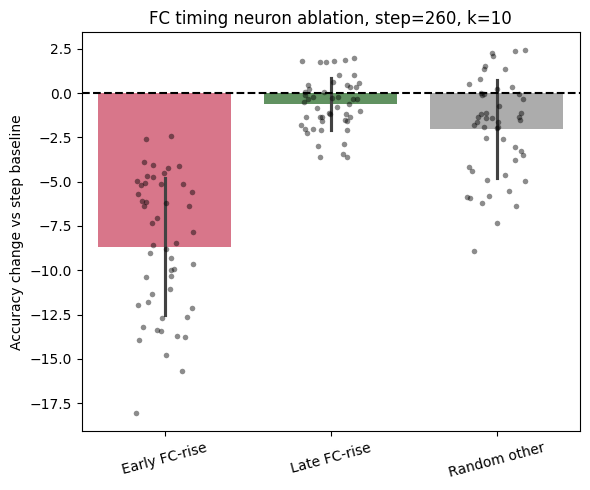


Lost sample grouping
Step: 260
sample_group
Unaffected correct    2212
Early-only lost       1936
Late-only lost         850
Both lost              401

Lost samples by true label
label              0   1    2    3   4   5   6    7    8    9
sample_group                                                 
Both lost          0   5  123  110   0  43  49    0   51   20
Early-only lost  482   3  279  387  60  28  96    0  563   38
Late-only lost     0  22    0   23   0   0   1  110   16  678

Specific lost group spread

Early-only lost
Count: 1936
Class coverage: 9 / 10
Label entropy: 2.4690461688713836
label
0    482
1      3
2    279
3    387
4     60
5     28
6     96
8    563
9     38

Late-only lost
Count: 850
Class coverage: 6 / 10
Label entropy: 1.0386309120915518
label
1     22
3     23
6      1
7    110
8     16
9    678

Metric summary
                baseline_confidence                           true_class_prob                           prob_margin                           logit_

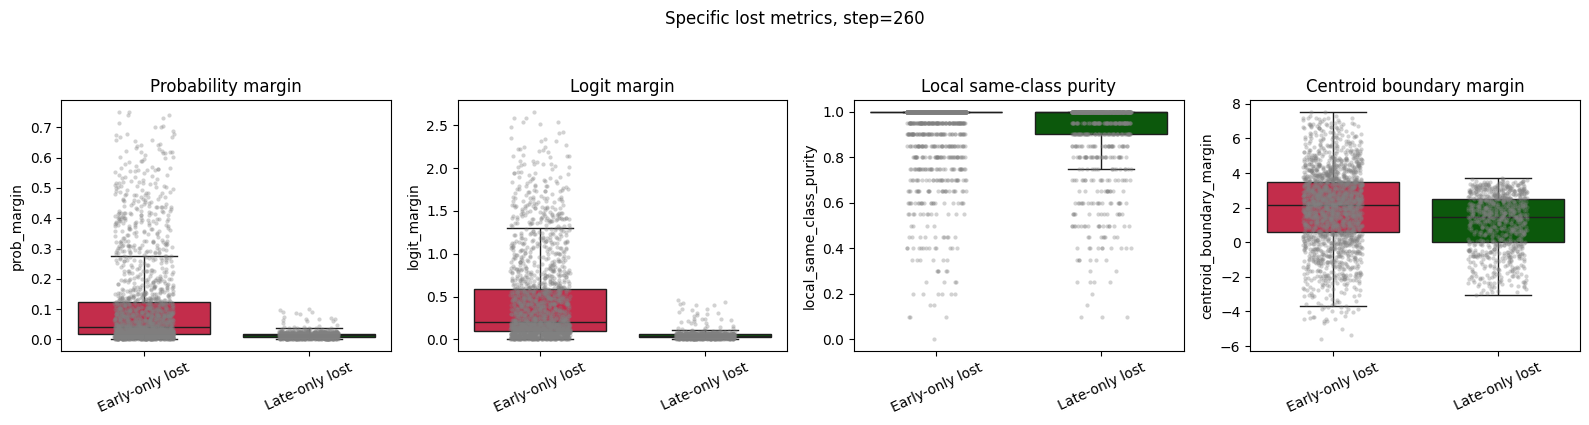


tSNE input
sample_group
Early-only lost       1936
Unaffected correct    1623
Late-only lost         850
Both lost              401


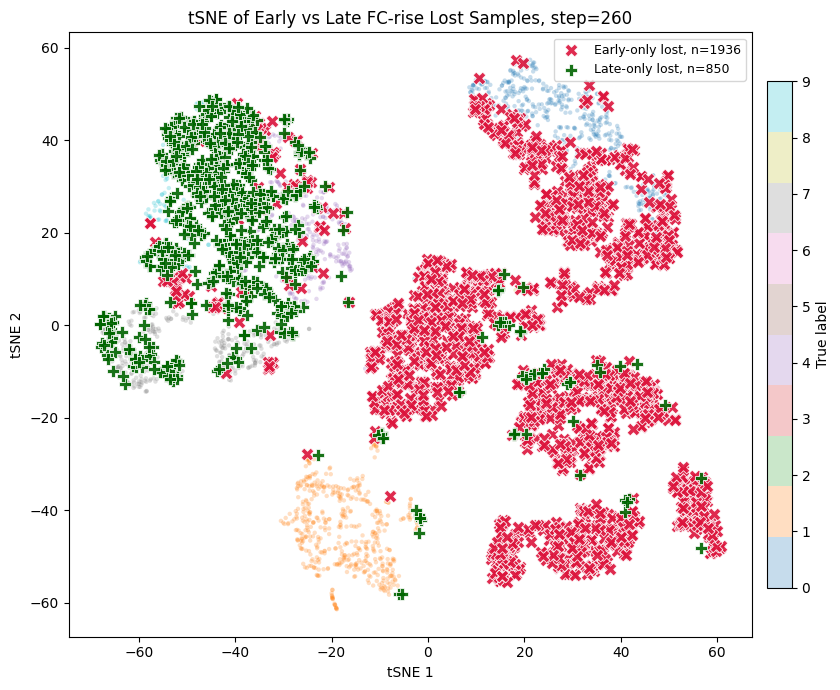


Analyzing model checkpoint: 280 actual index: 280

FC timing ablation setup
Model step: 280
Baseline accuracy: 64.68
Baseline loss: 1.2379241203308105
Early nodes: 15 [4, 21, 23, 29, 40, 56, 61, 62, 72, 76, 78, 80, 81, 83, 91]
Late nodes: 15 [7, 16, 19, 20, 30, 33, 35, 36, 37, 46, 49, 65, 77, 79, 96]
Random other pool: 70
k: 10 repeat: 50

Ablation summary
                  mean       std  count
Group                                  
Early FC-rise -11.6714  4.310139     50
Late FC-rise   -2.6178  0.860295     50
Random other   -2.9484  2.018566     50

Welch t-tests
Early FC-rise vs Late FC-rise: t=-14.5657, p=3.7397e-20
Early FC-rise vs Random other: t=-12.9598, p=3.2255e-20
Late FC-rise vs Random other: t=1.0654, p=2.9057e-01


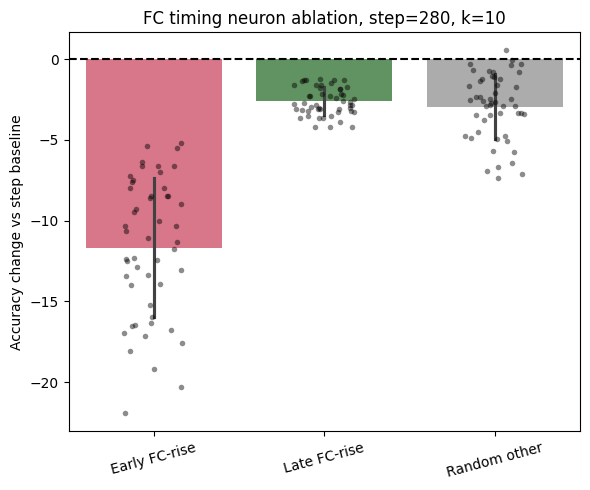


Lost sample grouping
Step: 280
sample_group
Unaffected correct    2918
Early-only lost       2634
Late-only lost         594
Both lost              322

Lost samples by true label
label              0   1    2    3   4    5    6    7    8    9
sample_group                                                   
Both lost          0   3   65    7   0   42   28    0  114   63
Early-only lost  422   1  433  549  23  291  424    0  420   71
Late-only lost     0  34    0   64   0    0   16  101    1  378

Specific lost group spread

Early-only lost
Count: 2634
Class coverage: 9 / 10
Label entropy: 2.7252369654349575
label
0    422
1      1
2    433
3    549
4     23
5    291
6    424
8    420
9     71

Late-only lost
Count: 594
Class coverage: 6 / 10
Label entropy: 1.5880889310431758
label
1     34
3     64
6     16
7    101
8      1
9    378

Metric summary
                baseline_confidence                           true_class_prob                           prob_margin                       

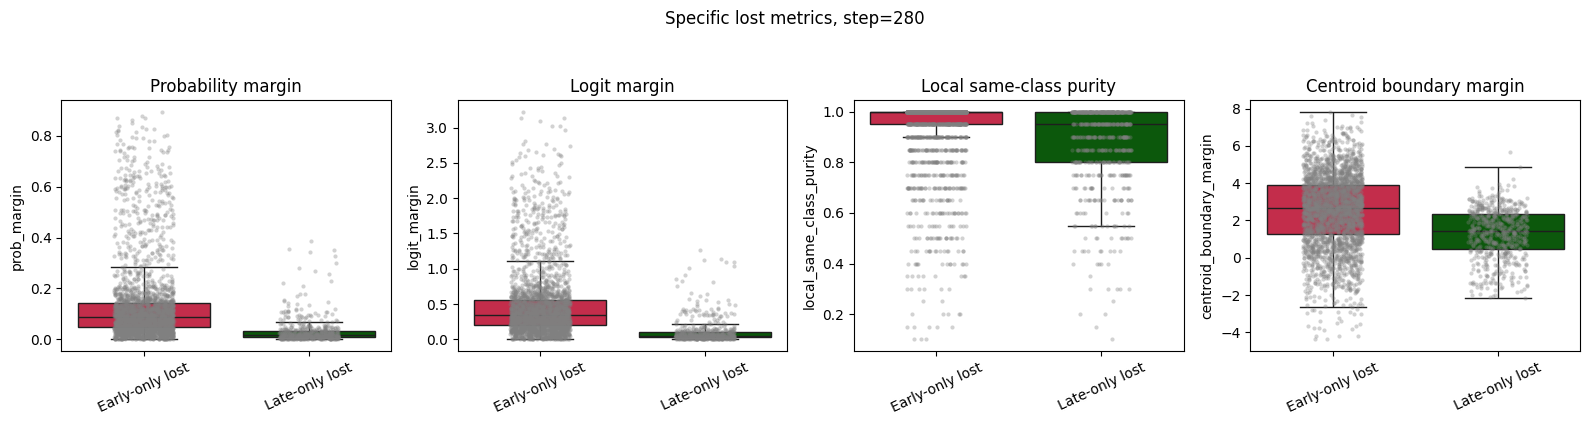


tSNE input
sample_group
Early-only lost       2634
Unaffected correct    2162
Late-only lost         594
Both lost              322


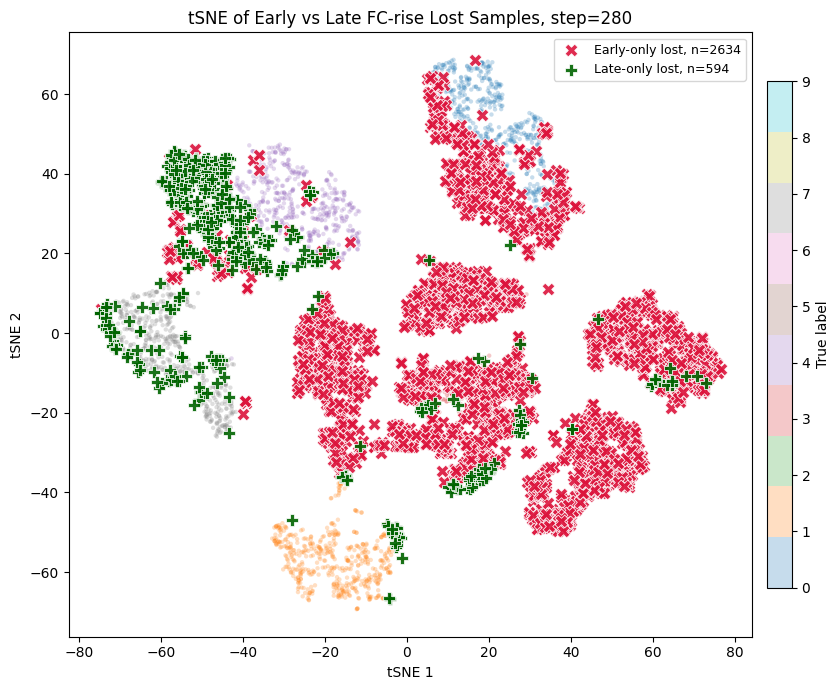


Analyzing model checkpoint: 300 actual index: 300

FC timing ablation setup
Model step: 300
Baseline accuracy: 72.36
Baseline loss: 0.9951641789436341
Early nodes: 15 [4, 21, 23, 29, 40, 56, 61, 62, 72, 76, 78, 80, 81, 83, 91]
Late nodes: 15 [7, 16, 19, 20, 30, 33, 35, 36, 37, 46, 49, 65, 77, 79, 96]
Random other pool: 70
k: 10 repeat: 50

Ablation summary
                  mean       std  count
Group                                  
Early FC-rise -14.4962  4.625568     50
Late FC-rise   -0.4048  0.312353     50
Random other   -2.2852  1.713088     50

Welch t-tests
Early FC-rise vs Late FC-rise: t=-21.4925, p=9.7610e-27
Early FC-rise vs Random other: t=-17.5049, p=1.0224e-25
Late FC-rise vs Random other: t=7.6358, p=4.6678e-10


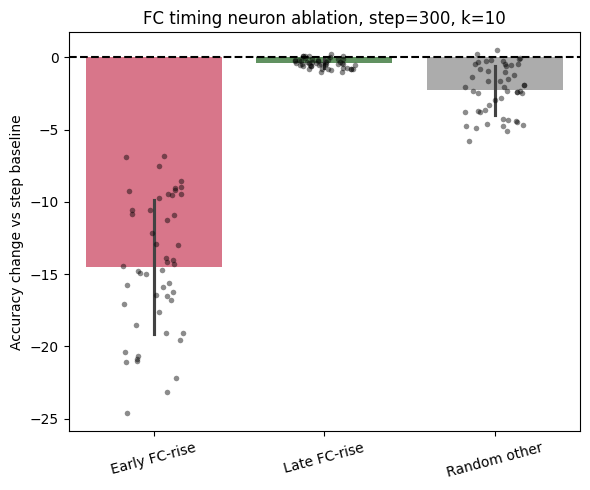


Lost sample grouping
Step: 300
sample_group
Early-only lost       3420
Unaffected correct    3156
Late-only lost         479
Both lost              181

Lost samples by true label
label              0   1    2    3   4    5    6   7    8    9
sample_group                                                  
Both lost          0   4   74    7   0   42    9   0   44    1
Early-only lost  593   0  536  436  95  342  587   0  691  140
Late-only lost     0  48    3   27   0    0    4  78   14  305

Specific lost group spread

Early-only lost
Count: 3420
Class coverage: 8 / 10
Label entropy: 2.8032905373661006
label
0    593
2    536
3    436
4     95
5    342
6    587
8    691
9    140

Late-only lost
Count: 479
Class coverage: 7 / 10
Label entropy: 1.6599520984030274
label
1     48
2      3
3     27
6      4
7     78
8     14
9    305

Metric summary
                baseline_confidence                           true_class_prob                           prob_margin                           l

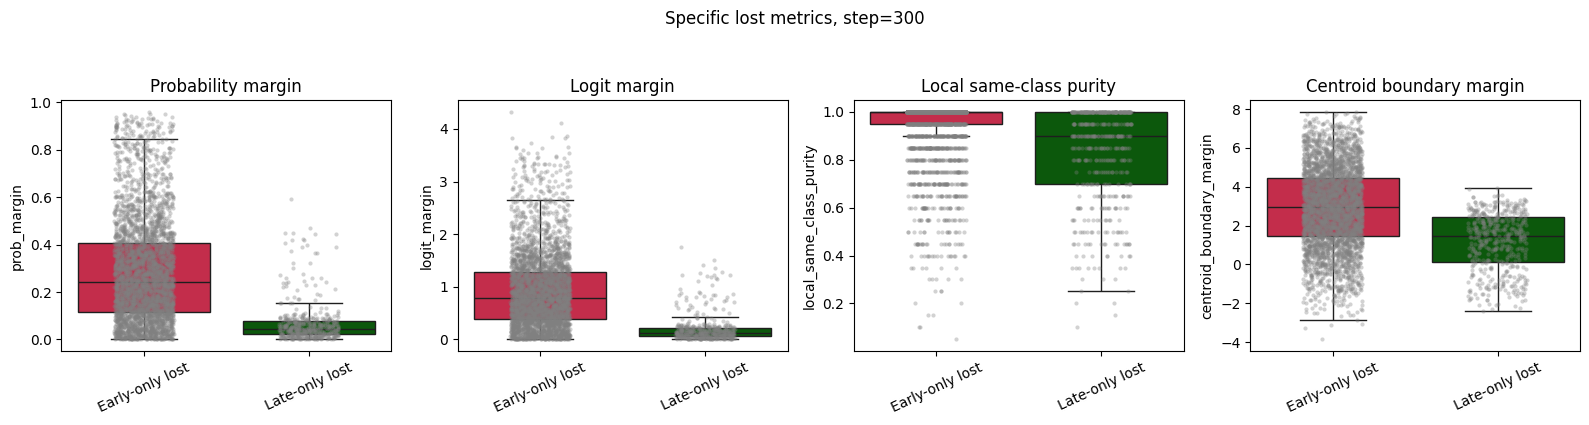


tSNE input
sample_group
Early-only lost       3420
Unaffected correct    2369
Late-only lost         479
Both lost              181


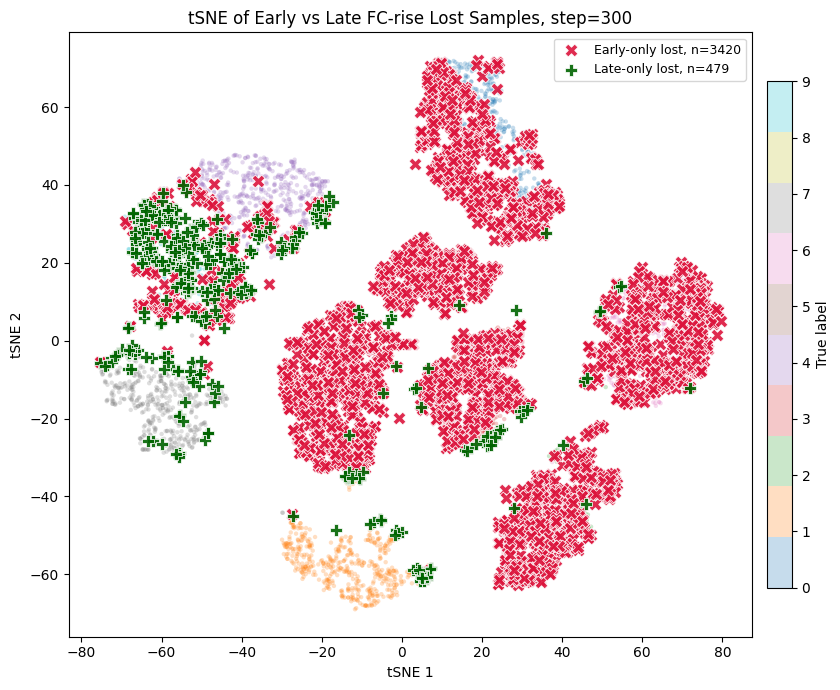


Analyzing model checkpoint: 400 actual index: 400

FC timing ablation setup
Model step: 400
Baseline accuracy: 83.03
Baseline loss: 0.575528506231308
Early nodes: 15 [4, 21, 23, 29, 40, 56, 61, 62, 72, 76, 78, 80, 81, 83, 91]
Late nodes: 15 [7, 16, 19, 20, 30, 33, 35, 36, 37, 46, 49, 65, 77, 79, 96]
Random other pool: 70
k: 10 repeat: 50

Ablation summary
                  mean       std  count
Group                                  
Early FC-rise -17.0192  5.357241     50
Late FC-rise   -1.2924  0.467230     50
Random other   -1.3366  0.998267     50

Welch t-tests
Early FC-rise vs Late FC-rise: t=-20.6794, p=4.4304e-26
Early FC-rise vs Random other: t=-20.3493, p=1.5422e-26
Late FC-rise vs Random other: t=0.2836, p=7.7759e-01


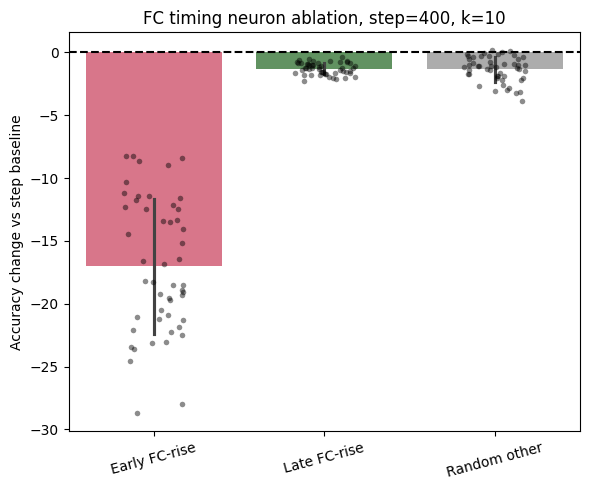


Lost sample grouping
Step: 400
sample_group
Early-only lost       3946
Unaffected correct    3830
Late-only lost         301
Both lost              226

Lost samples by true label
label              0    1    2    3   4    5    6   7    8    9
sample_group                                                   
Both lost          0    6   32   37   0   59    3   0   89    0
Early-only lost  642    2  627  485  51  551  820   0  671   97
Late-only lost     0  101    5   18   0    2    1  34    4  136

Specific lost group spread

Early-only lost
Count: 3946
Class coverage: 9 / 10
Label entropy: 2.7399501706422815
label
0    642
1      2
2    627
3    485
4     51
5    551
6    820
8    671
9     97

Late-only lost
Count: 301
Class coverage: 8 / 10
Label entropy: 1.9013394997800095
label
1    101
2      5
3     18
5      2
6      1
7     34
8      4
9    136

Metric summary
                baseline_confidence                           true_class_prob                           prob_margin     

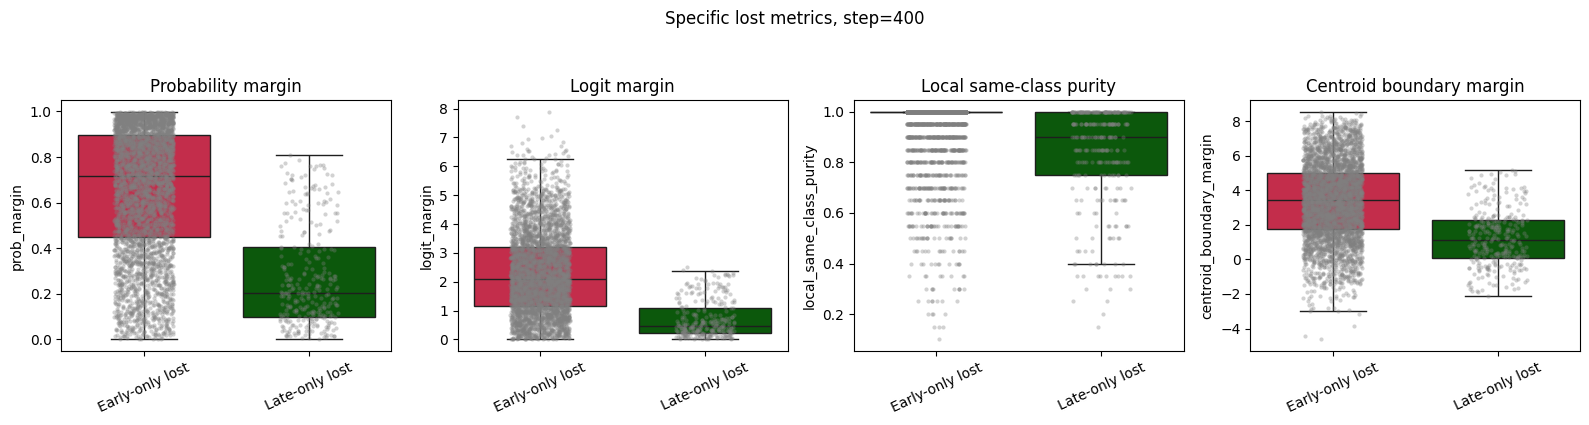


tSNE input
sample_group
Early-only lost       3946
Unaffected correct    2746
Late-only lost         301
Both lost              226


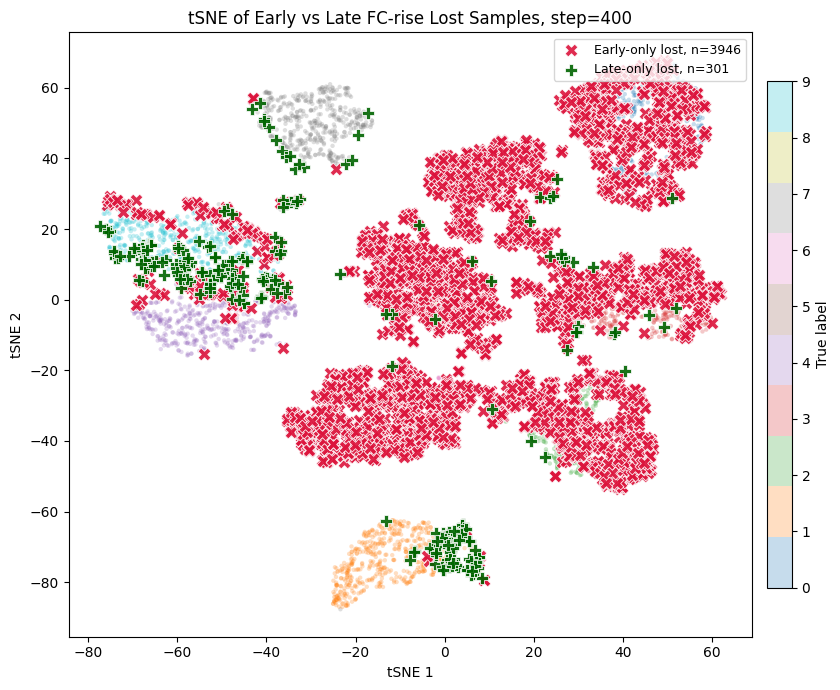


Analyzing model checkpoint: 600 actual index: 600

FC timing ablation setup
Model step: 600
Baseline accuracy: 88.51
Baseline loss: 0.3896410608768463
Early nodes: 15 [4, 21, 23, 29, 40, 56, 61, 62, 72, 76, 78, 80, 81, 83, 91]
Late nodes: 15 [7, 16, 19, 20, 30, 33, 35, 36, 37, 46, 49, 65, 77, 79, 96]
Random other pool: 70
k: 10 repeat: 50

Ablation summary
                  mean       std  count
Group                                  
Early FC-rise -13.0092  4.077228     50
Late FC-rise   -1.4606  0.593799     50
Random other   -1.1218  0.877484     50

Welch t-tests
Early FC-rise vs Late FC-rise: t=-19.8195, p=1.2278e-25
Early FC-rise vs Random other: t=-20.1546, p=1.1625e-26
Late FC-rise vs Random other: t=-2.2611, p=2.6273e-02


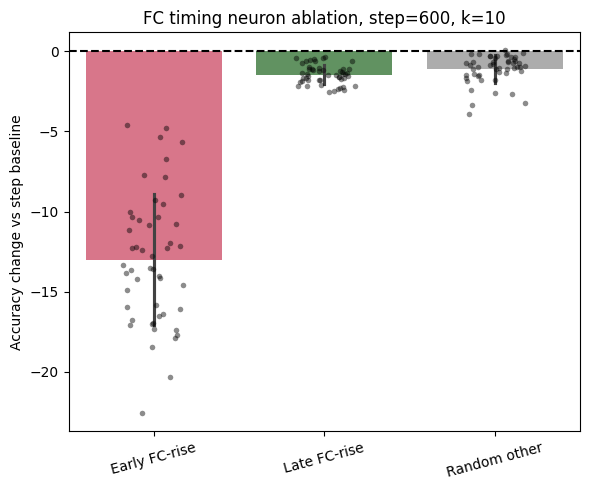


Lost sample grouping
Step: 600
sample_group
Unaffected correct    4940
Early-only lost       3504
Late-only lost         253
Both lost              154

Lost samples by true label
label              0    1    2    3    5    6   7    8   9
sample_group                                              
Both lost          0    5   15   14    8    1   0   88  23
Early-only lost  600    0  529  361  535  713   0  667  99
Late-only lost     0  133    8   14    7    0  10    3  78

Specific lost group spread

Early-only lost
Count: 3504
Class coverage: 7 / 10
Label entropy: 2.6678872608557502
label
0    600
2    529
3    361
5    535
6    713
8    667
9     99

Late-only lost
Count: 253
Class coverage: 7 / 10
Label entropy: 1.802983460832016
label
1    133
2      8
3     14
5      7
7     10
8      3
9     78

Metric summary
                baseline_confidence                           true_class_prob                           prob_margin                           logit_margin                   

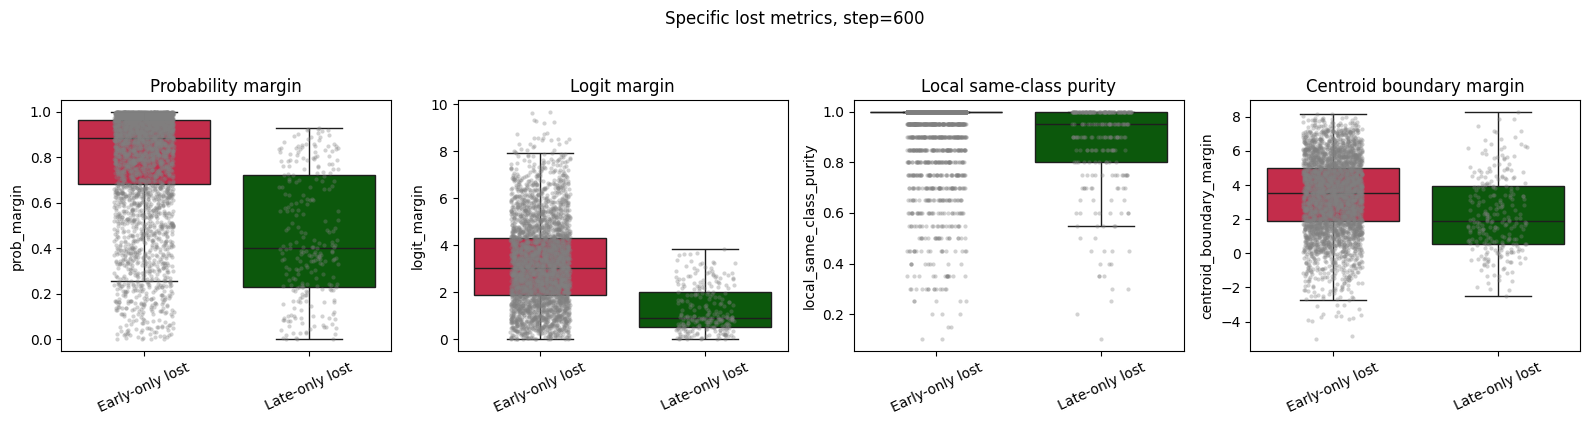


tSNE input
sample_group
Unaffected correct    3544
Early-only lost       3504
Late-only lost         253
Both lost              154


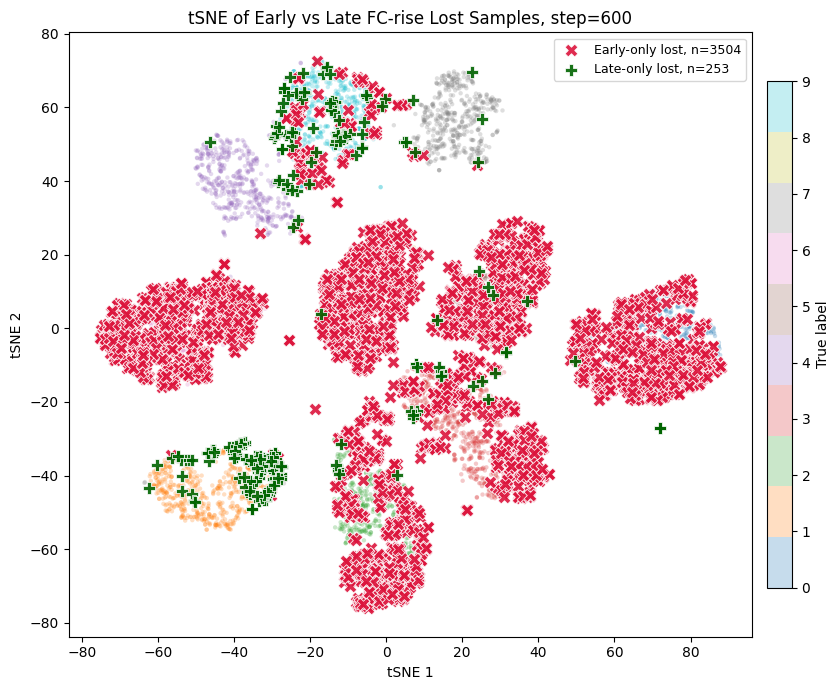


Analyzing model checkpoint: 800 actual index: 800

FC timing ablation setup
Model step: 800
Baseline accuracy: 90.58
Baseline loss: 0.3194494035243988
Early nodes: 15 [4, 21, 23, 29, 40, 56, 61, 62, 72, 76, 78, 80, 81, 83, 91]
Late nodes: 15 [7, 16, 19, 20, 30, 33, 35, 36, 37, 46, 49, 65, 77, 79, 96]
Random other pool: 70
k: 10 repeat: 50

Ablation summary
                  mean       std  count
Group                                  
Early FC-rise -13.3962  4.224561     50
Late FC-rise   -1.0928  0.685152     50
Random other   -0.9694  0.693984     50

Welch t-tests
Early FC-rise vs Late FC-rise: t=-20.3278, p=2.7887e-26
Early FC-rise vs Random other: t=-20.5249, p=1.7108e-26
Late FC-rise vs Random other: t=-0.8947, p=3.7312e-01


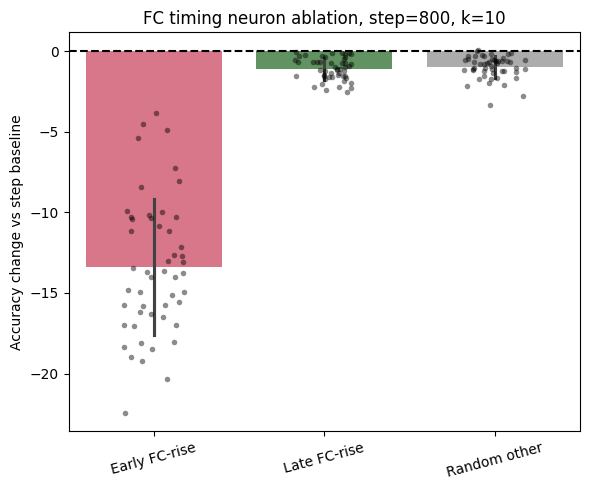


Lost sample grouping
Step: 800
sample_group
Unaffected correct    5571
Early-only lost       3163
Late-only lost         202
Both lost              122

Lost samples by true label
label              0    1    2    3  4    5    6   7    8   9
sample_group                                                 
Both lost          0    4   10   10  0   13    2   0   60  23
Early-only lost  675    0  521  207  0  432  582   0  698  48
Late-only lost     0  144    0    9  1    3    1  14    0  30

Specific lost group spread

Early-only lost
Count: 3163
Class coverage: 7 / 10
Label entropy: 2.5759704593463733
label
0    675
2    521
3    207
5    432
6    582
8    698
9     48

Late-only lost
Count: 202
Class coverage: 7 / 10
Label entropy: 1.3895822773067488
label
1    144
3      9
4      1
5      3
6      1
7     14
9     30

Metric summary
                baseline_confidence                           true_class_prob                           prob_margin                           logit_margin   

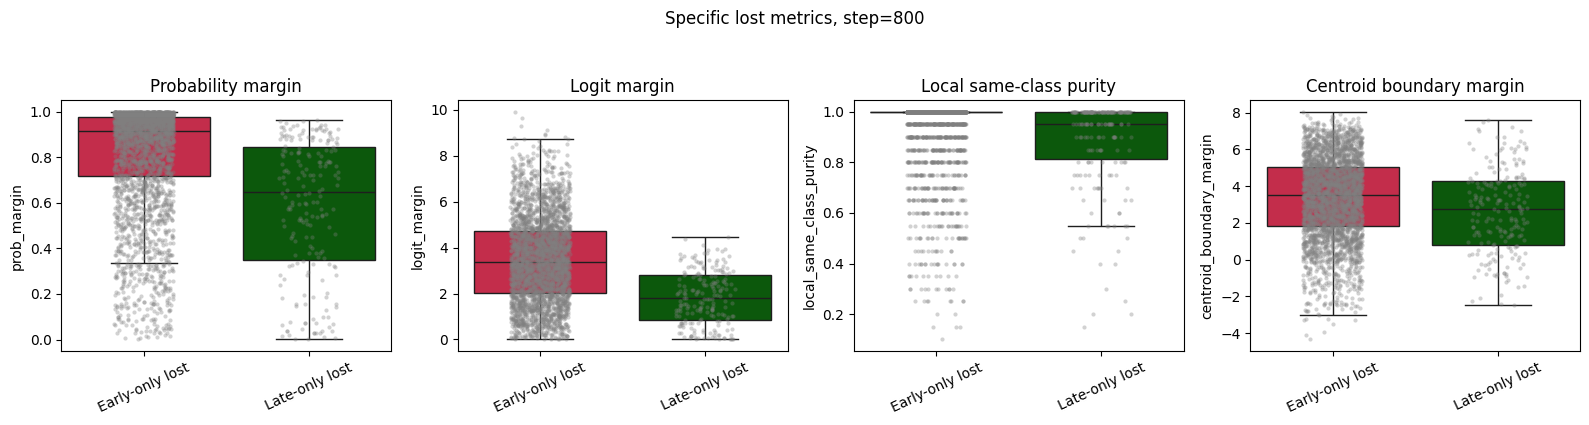


tSNE input
sample_group
Unaffected correct    3801
Early-only lost       3163
Late-only lost         202
Both lost              122


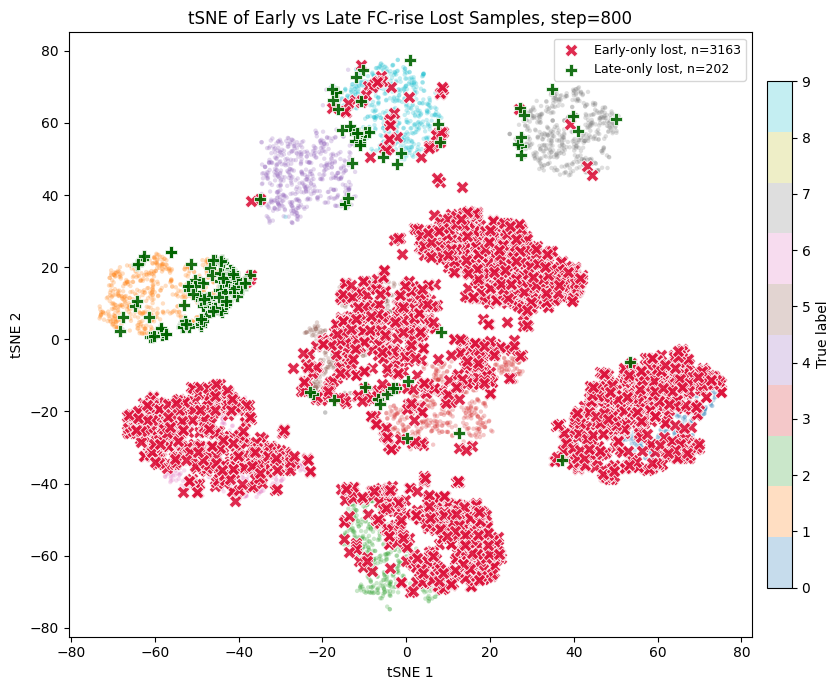


Analyzing model checkpoint: last actual index: 1174

FC timing ablation setup
Model step: last
Baseline accuracy: 93.17
Baseline loss: 0.2320163201570511
Early nodes: 15 [4, 21, 23, 29, 40, 56, 61, 62, 72, 76, 78, 80, 81, 83, 91]
Late nodes: 15 [7, 16, 19, 20, 30, 33, 35, 36, 37, 46, 49, 65, 77, 79, 96]
Random other pool: 70
k: 10 repeat: 50

Ablation summary
                  mean       std  count
Group                                  
Early FC-rise -12.5968  4.985353     50
Late FC-rise   -1.0120  0.475721     50
Random other   -1.0972  0.989019     50

Welch t-tests
Early FC-rise vs Late FC-rise: t=-16.3572, p=1.0928e-21
Early FC-rise vs Random other: t=-15.9989, p=6.5844e-22
Late FC-rise vs Random other: t=0.5489, p=5.8478e-01


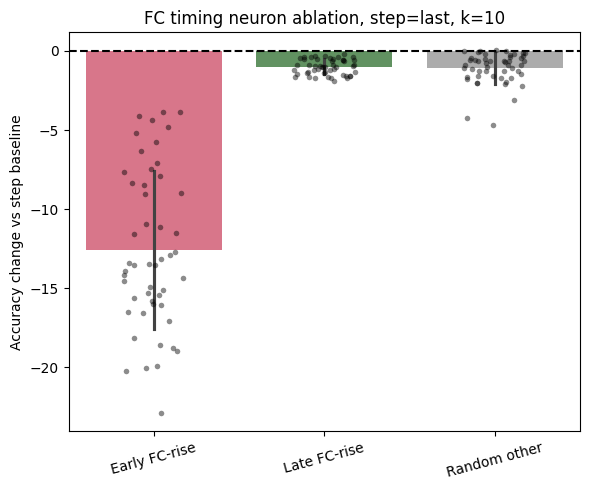


Lost sample grouping
Step: last
sample_group
Unaffected correct    5571
Early-only lost       3423
Late-only lost         216
Both lost              107

Lost samples by true label
label              0    1    2    3  4    5    6  7    8   9
sample_group                                                
Both lost          0    5    6    9  0   16    3  0   34  34
Early-only lost  765    0  595  167  1  321  706  0  825  43
Late-only lost     0  153    0   13  1    0    1  8    0  40

Specific lost group spread

Early-only lost
Count: 3423
Class coverage: 8 / 10
Label entropy: 2.501960839323347
label
0    765
2    595
3    167
4      1
5    321
6    706
8    825
9     43

Late-only lost
Count: 216
Class coverage: 6 / 10
Label entropy: 1.2948727796481703
label
1    153
3     13
4      1
6      1
7      8
9     40

Metric summary
                baseline_confidence                           true_class_prob                           prob_margin                           logit_margin        

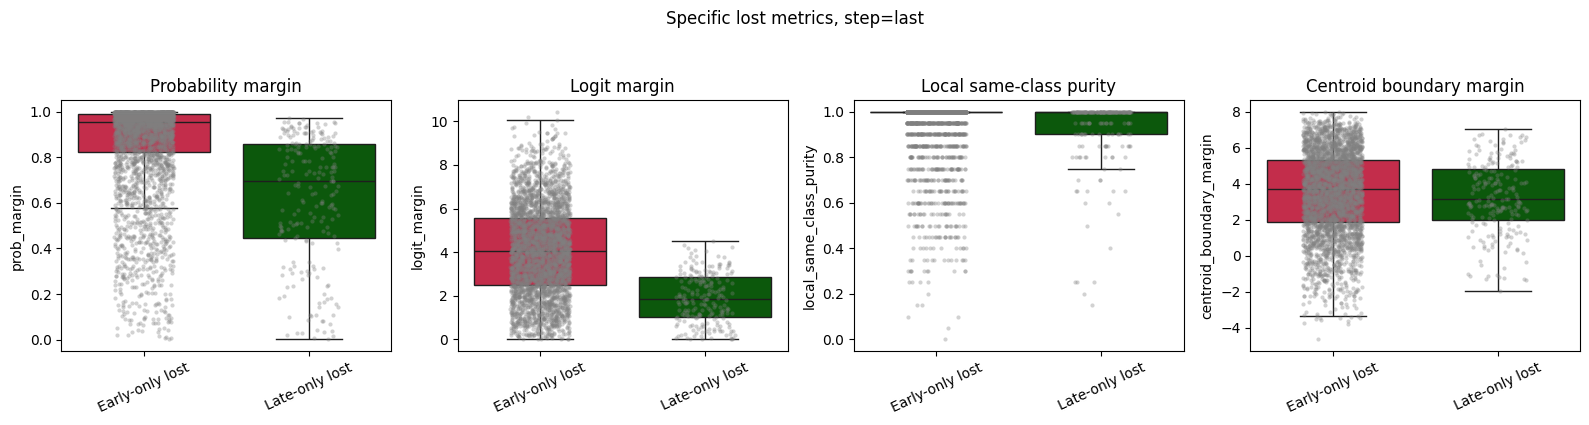


tSNE input
sample_group
Unaffected correct    3714
Early-only lost       3423
Late-only lost         216
Both lost              107


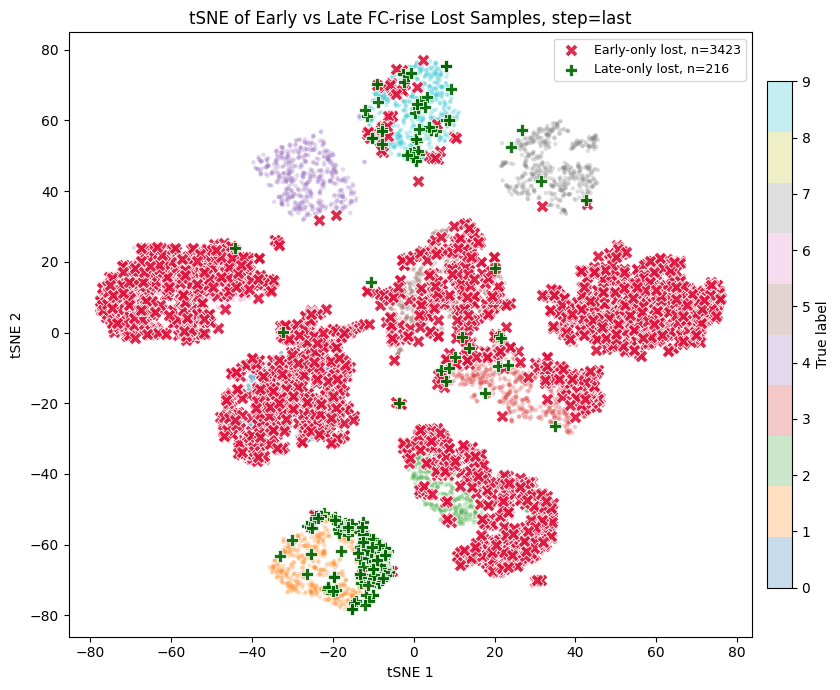


All-step ablation summary
                       mean       std  count
Step Group                                  
260  Early FC-rise  -8.6662  3.868184     50
     Late FC-rise   -0.6382  1.469818     50
     Random other   -2.0220  2.744578     50
280  Early FC-rise -11.6714  4.310139     50
     Late FC-rise   -2.6178  0.860295     50
     Random other   -2.9484  2.018566     50
300  Early FC-rise -14.4962  4.625568     50
     Late FC-rise   -0.4048  0.312353     50
     Random other   -2.2852  1.713088     50
400  Early FC-rise -17.0192  5.357241     50
     Late FC-rise   -1.2924  0.467230     50
     Random other   -1.3366  0.998267     50
600  Early FC-rise -13.0092  4.077228     50
     Late FC-rise   -1.4606  0.593799     50
     Random other   -1.1218  0.877484     50
800  Early FC-rise -13.3962  4.224561     50
     Late FC-rise   -1.0928  0.685152     50
     Random other   -0.9694  0.693984     50
last Early FC-rise -12.5968  4.985353     50
     Late FC-rise   -1.0120 

In [9]:
analysis_model_steps = [260, 280, 300, 400, 600, 800, "last"]
# analysis_model_steps = [260]

neuron_timing_result = select_top_timing_neurons(
    early_pairs=fc_rise_result["early_rise_pairs"],
    late_pairs=fc_rise_result["late_rise_pairs"],
    hidden_size=hidden_dims[1],
    n_select=n_extreme_neurons,
    min_total_pairs=5
)

early_idx = neuron_timing_result["early_idx"]
late_idx = neuron_timing_result["late_idx"]

multi_step_results, df_fc_timing_ablation_all, df_fc_timing_specific_all = run_multi_step_fc_timing_analysis(
    models=models,
    model_steps=analysis_model_steps,
    input_size=input_size,
    hidden_dims=hidden_dims,
    act=act,
    test_loader=test_loader,
    early_idx=early_idx,
    late_idx=late_idx,
    layer_index=1,
    k=10,
    repeat=50,
    seed=42,
    run_tsne=True,
    plot_metrics=True,
    max_unaffected_per_class=500
)

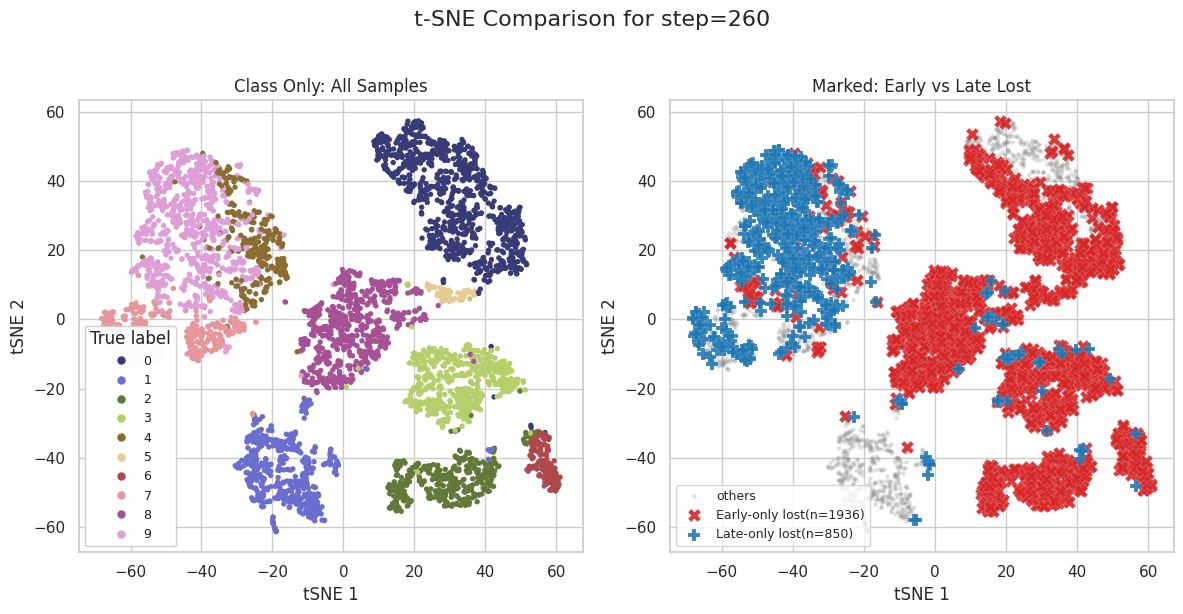

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne_side_by_side(tsne_df, step_label=""):
    # 创建 1行2列 的画布，尺寸适当加宽
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # ==========================================
    # 左图：仅展示类别颜色的 t-SNE (原右图)
    # ==========================================
    # 建议使用 tab10 调色板，对于 10 个离散类别的区分度最佳
    sc_class = axes[0].scatter(tsne_df["TSNE1"], tsne_df["TSNE2"], c=tsne_df["label"], cmap=plt.get_cmap("tab20b"), s=15, alpha=1, linewidths=0)
    
    axes[0].set_title("Class Only: All Samples")
    axes[0].set_xlabel("tSNE 1")
    axes[0].set_ylabel("tSNE 2")
    
    # 添加离散的类别图例替代 Colorbar
    # sc_class.legend_elements() 会自动提取散点图中的所有离散颜色并生成句柄
    legend_class = axes[0].legend(*sc_class.legend_elements(), title="True label", loc="best", frameon=True, fontsize=9)
    axes[0].add_artist(legend_class)

    # ==========================================
    # 右图：带有 Early / Late 特殊标记的 t-SNE (原左图)
    # ==========================================
    base = tsne_df[tsne_df["sample_group"] == "Unaffected correct"]
    lost = tsne_df[tsne_df["sample_group"].isin(["Early-only lost", "Late-only lost"])]
    
    # 画背景点
    axes[1].scatter(base["TSNE1"], base["TSNE2"], c='gray', s=10, alpha=0.25, linewidths=0, label="others")
    
    # 画特定丢失点
    marker_map = {"Early-only lost": ("X", "tab:red"), "Late-only lost": ("P", "tab:blue")}
    for g, item in marker_map.items():
        marker, color = item
        sub = lost[lost["sample_group"] == g]
        if len(sub) > 0:
            axes[1].scatter(sub["TSNE1"], sub["TSNE2"], s=85, marker=marker, c=color, edgecolors="white", linewidths=0.1, alpha=0.9, label=f"{g}(n={len(sub)})")
            
    axes[1].legend(loc="best", frameon=True, fontsize=9)
    axes[1].set_title("Marked: Early vs Late Lost")
    axes[1].set_xlabel("tSNE 1")
    axes[1].set_ylabel("tSNE 2")

    # ==========================================
    # 统一样式与主标题
    # ==========================================
    fig.suptitle(f"t-SNE Comparison for step={step_label}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(f"./fig/tsne_comparison_step_{step_label}.pdf", format='pdf', bbox_inches='tight')
    plt.show()

# ==========================================
# 提取特定步数的数据并绘图
step_key = "260" 
# ==========================================

if step_key in multi_step_results:
    tsne_df = multi_step_results[step_key].get("tsne_df")
    
    if tsne_df is not None:
        plot_tsne_side_by_side(tsne_df=tsne_df, step_label=step_key)
    else:
        print(f"步数 '{step_key}' 的 t-SNE 数据为空。")
else:
    print(f"未在 multi_step_results 中找到步数 '{step_key}' 的结果。")

Step 260 样本统计:
sample_group
Unaffected correct    2488
Early-only lost       1637
Late-only lost         381
Both lost              253


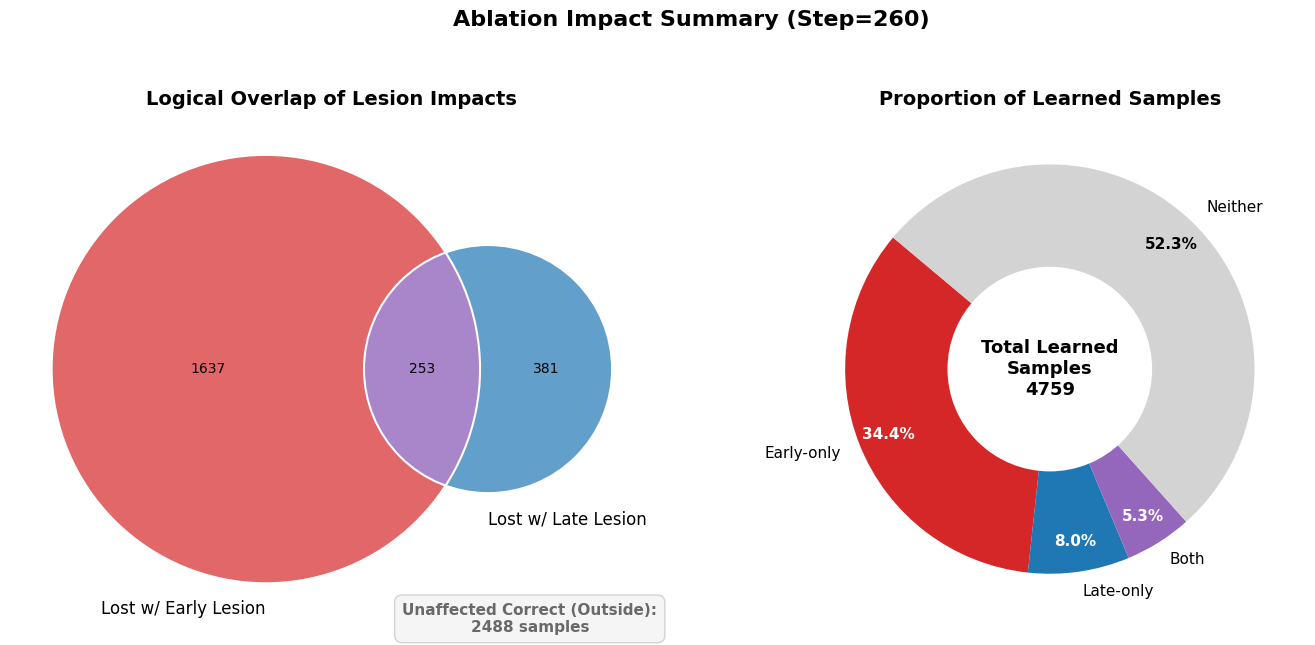

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2, venn2_circles

def plot_lesion_impact_summary(early_only, late_only, both_lost, unaffected, step_label="260"):
    """
    绘制韦恩图和环形图，展示不同神经元切除对基线正确样本的影响。
    """
    total_correct = early_only + late_only + both_lost + unaffected
    
    # 设置一致的配色风格
    color_early = "tab:red"
    color_late = "tab:blue" # 如果你之前用绿色，可以换成 "tab:green"
    color_both = "tab:purple"
    color_unaffected = "lightgray"

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ==========================================
    # 左图：逻辑韦恩图 (Venn Diagram)
    # ==========================================
    ax_venn = axes[0]
    
    # 传入的 subsets 参数格式为 (Set_A_Only, Set_B_Only, Intersection)
    v = venn2(subsets=(early_only, late_only, both_lost), 
              set_labels=('Lost w/ Early Lesion', 'Lost w/ Late Lesion'),
              set_colors=(color_early, color_late), 
              alpha=0.7, ax=ax_venn)
    
    # 调整交集部分的颜色为紫色
    if v.get_patch_by_id('11'):
        v.get_patch_by_id('11').set_color(color_both)
        v.get_patch_by_id('11').set_alpha(0.8)
        
    # 添加圆圈边界线让图表更清晰
    venn2_circles(subsets=(early_only, late_only, both_lost), linestyle='solid', linewidth=1.5, color='white', ax=ax_venn)

    # 在韦恩图外部标注 Unaffected correct 的数量
    ax_venn.text(0.5, -0.6, f"Unaffected Correct (Outside):\n{unaffected} samples", 
                 horizontalalignment='center', verticalalignment='center', 
                 fontsize=11, color='dimgray', weight='bold',
                 bbox=dict(facecolor='whitesmoke', edgecolor='lightgray', boxstyle='round,pad=0.5'))

    ax_venn.set_title("Logical Overlap of Lesion Impacts", fontsize=14, fontweight='bold')

    # ==========================================
    # 右图：环形比例图 (Donut Chart)
    # ==========================================
    ax_pie = axes[1]
    
    sizes = [early_only, late_only, both_lost, unaffected]
    labels = ['Early-only', 'Late-only', 'Both', 'Neither']
    colors = [color_early, color_late, color_both, color_unaffected]
    explode = (0, 0, 0, 0) # 把丢失的样本稍微弹出来一点
    
    # 画饼图
    wedges, texts, autotexts = ax_pie.pie(sizes, explode=explode, labels=labels, colors=colors, 
                                          autopct='%1.1f%%', startangle=140, pctdistance=0.85,
                                          textprops=dict(color="black", fontsize=11))
    
    # 画中间的白圆，变成环形图
    centre_circle = plt.Circle((0,0), 0.50, fc='white')
    ax_pie.add_artist(centre_circle)
    
    # 在中心写上总样本数
    ax_pie.text(0, 0, f"Total Learned\nSamples\n{total_correct}", 
                horizontalalignment='center', verticalalignment='center', 
                fontsize=13, fontweight='bold', color='black')

    # 优化百分比文本的样式
    for autotext in autotexts:
        autotext.set_weight('bold')
        autotext.set_color('white')
    # Unaffected 比例由于底色是浅灰，把文字改黑
    autotexts[3].set_color('black')

    ax_pie.set_title("Proportion of Learned Samples", fontsize=14, fontweight='bold')

    # ==========================================
    # 整体排版
    # ==========================================
    fig.suptitle(f"Ablation Impact Summary (Step={step_label})", fontsize=16, y=1.05, fontweight='bold')
    plt.tight_layout()
    # plt.savefig('./fig/Proportion of Learned Samples.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# 设定你要分析的步数
step_key = "260"

# 1. 确保该步数存在于结果字典中
if step_key in multi_step_results:
    # 2. 提取对应的 t-SNE DataFrame
    tsne_df = multi_step_results[step_key].get("tsne_df")
    
    if tsne_df is not None:
        # 3. 自动统计 sample_group 列中各个类别的数量
        counts = tsne_df["sample_group"].value_counts()
        
        # 4. 打印一下提取到的统计数据（可选，用于检查）
        print(f"Step {step_key} 样本统计:")
        print(counts.to_string())
        
        # 5. 代入作图函数
        plot_lesion_impact_summary(
            early_only=counts.get("Early-only lost", 0),
            late_only=counts.get("Late-only lost", 0),
            both_lost=counts.get("Both lost", 0),
            unaffected=counts.get("Unaffected correct", 0),
            step_label=step_key
        )
    else:
        print(f"步数 '{step_key}' 的 t-SNE 数据为空。")
else:
    print(f"未在 multi_step_results 中找到步数 '{step_key}' 的结果。")

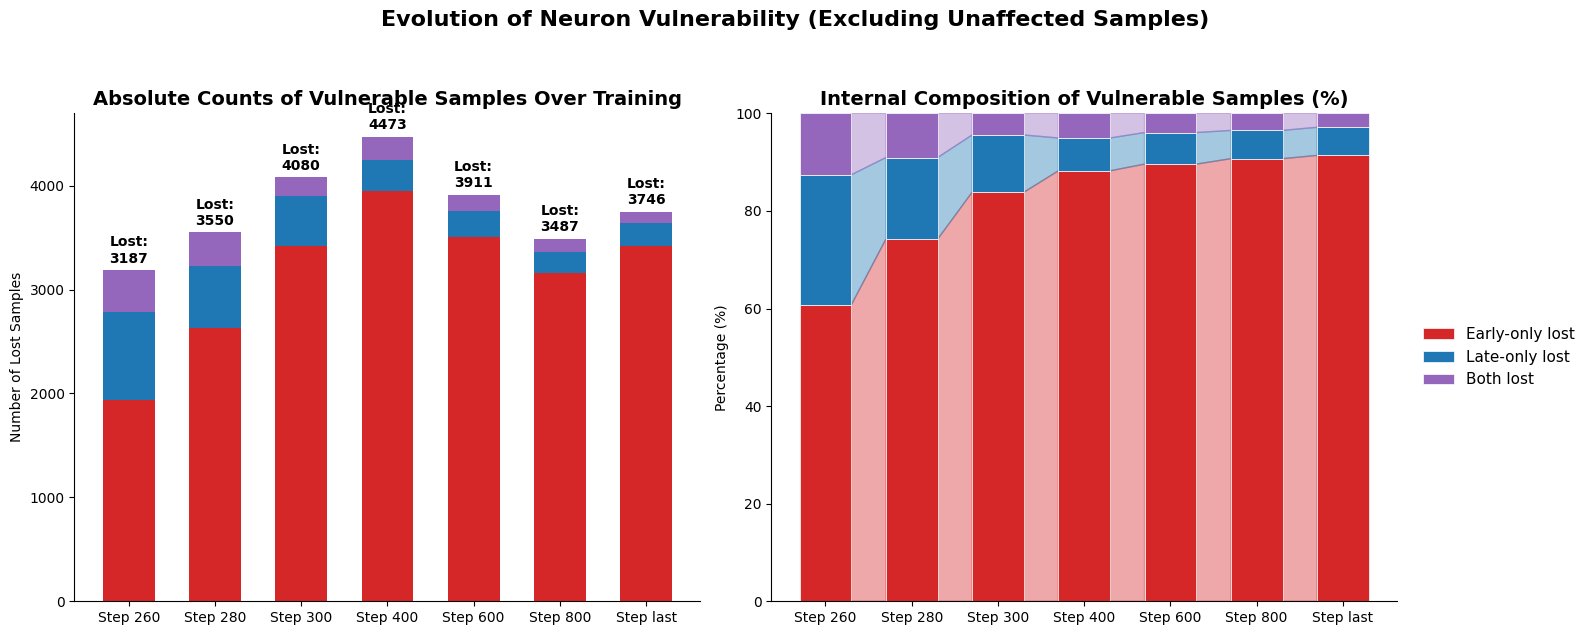

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_lesion_impact_evolution_zoomed(multi_step_results):
    """
    剔除 Unaffected 样本，仅展示 Early-only, Late-only, Both lost 
    这三类脆弱样本随训练步骤的绝对数量与相对比例演化，并在右图添加透明过渡彩带。
    """
    steps = []
    early_counts = []
    late_counts = []
    both_counts = []
    
    # 对步数进行排序，确保时间顺序正确 (数字升序，"last" 放最后)
    numeric_keys = sorted([k for k in multi_step_results.keys() if k != "last"], key=int)
    sorted_keys = numeric_keys + (["last"] if "last" in multi_step_results else [])
    
    # 提取真实数量
    for key in sorted_keys:
        info_df = multi_step_results[key].get("info_metrics")
        if info_df is None:
            info_df = multi_step_results[key].get("info")
            
        if info_df is not None:
            counts = info_df["sample_group"].value_counts()
            steps.append(f"Step {key}")
            early_counts.append(counts.get("Early-only lost", 0))
            late_counts.append(counts.get("Late-only lost", 0))
            both_counts.append(counts.get("Both lost", 0))
        else:
            print(f"警告：找不到 Step {key} 的 info 数据，已跳过。")

    if not steps:
        print("没有可用于绘制演化图的数据。")
        return

    # 转换为 NumPy 数组以便于向量化计算
    early_arr = np.array(early_counts)
    late_arr = np.array(late_counts)
    both_arr = np.array(both_counts)
    
    # 核心修改：重新计算 Total，现在只包含“丢失的样本”
    totals = early_arr + late_arr + both_arr
    
    # 防止除以 0 的安全处理
    totals_safe = np.where(totals == 0, 1, totals)

    # 设置颜色 (保持与之前图表一致的配色)
    colors = {
        'Early-only lost': 'tab:red',
        'Late-only lost': 'tab:blue',
        'Both lost': 'tab:purple'
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    x = np.arange(len(steps))
    width = 0.6

    # ==========================================
    # 左图：脆弱样本的绝对数量堆积图 (Absolute Counts)
    # ==========================================
    axes[0].bar(x, early_arr, width, label='Early-only lost', color=colors['Early-only lost'])
    axes[0].bar(x, late_arr, width, bottom=early_arr, label='Late-only lost', color=colors['Late-only lost'])
    axes[0].bar(x, both_arr, width, bottom=early_arr + late_arr, label='Both lost', color=colors['Both lost'])

    # 在顶部标注总脆弱样本数
    for i, total in enumerate(totals):
        axes[0].text(x[i], total + max(totals)*0.01, f"Lost:\n{total}", ha='center', va='bottom', fontsize=10, fontweight='bold')

    axes[0].set_title("Absolute Counts of Vulnerable Samples Over Training", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Number of Lost Samples")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(steps)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # ==========================================
    # 右图：脆弱样本内部的 100% 相对比例堆积图 (含透明带)
    # ==========================================
    # 计算百分比
    early_pct = early_arr / totals_safe * 100
    late_pct = late_arr / totals_safe * 100
    both_pct = both_arr / totals_safe * 100

    # 绘制比例柱状图，添加白色边缘线使区块更清晰
    axes[1].bar(x, early_pct, width, label='Early-only lost', color=colors['Early-only lost'], edgecolor='white', linewidth=0.5)
    axes[1].bar(x, late_pct, width, bottom=early_pct, label='Late-only lost', color=colors['Late-only lost'], edgecolor='white', linewidth=0.5)
    axes[1].bar(x, both_pct, width, bottom=early_pct + late_pct, label='Both lost', color=colors['Both lost'], edgecolor='white', linewidth=0.5)

    # 整合百分比数据以便循环生成彩带
    pct_data = np.array([early_pct, late_pct, both_pct])
    ribbon_colors_list = [colors['Early-only lost'], colors['Late-only lost'], colors['Both lost']]

    # 添加全覆盖的过渡彩带
    for j in range(len(steps) - 1):
        left_x = x[j] + width / 2
        right_x = x[j+1] - width / 2
        
        left_data = pct_data[:, j]
        right_data = pct_data[:, j+1]
        
        left_cumsum = np.cumsum(left_data)
        right_cumsum = np.cumsum(right_data)
        
        # 添加从底部到顶部的所有彩带
        for i in range(len(ribbon_colors_list)):
            left_bottom = left_cumsum[i-1] if i > 0 else 0
            left_top = left_cumsum[i]
            right_bottom = right_cumsum[i-1] if i > 0 else 0
            right_top = right_cumsum[i]
            
            # 使用 zorder=0 将彩带放在柱子下方，避免干扰白色边框
            axes[1].fill([left_x, right_x, right_x, left_x],
                         [left_bottom, right_bottom, right_top, left_top],
                         color=ribbon_colors_list[i], alpha=0.4, zorder=0)

    # 在柱子内部写入百分比文本
    # for i in range(len(steps)):
    #     y_offset = 0
    #     # 依次为 early, late, both 写入文字
    #     for pct, val in zip([early_pct, late_pct, both_pct], [early_arr, late_arr, both_arr]):
    #         if pct[i] > 1: # 只有占比大于 5% 才写字，避免太拥挤
    #             axes[1].text(x[i], y_offset + pct[i]/2, f"{pct[i]:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    #         y_offset += pct[i]

    axes[1].set_title("Internal Composition of Vulnerable Samples (%)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Percentage (%)")
    axes[1].set_ylim(0, 100)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(steps)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    # 共享图例放在右图外侧
    axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11, frameon=False)

    fig.suptitle("Evolution of Neuron Vulnerability (Excluding Unaffected Samples)", fontsize=16, y=1.05, fontweight='bold')
    plt.tight_layout()
    # plt.savefig('./fig/Evolution of Neuron Vulnerability Zoomed.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# ==========================================
# 直接执行调用
# ==========================================
plot_lesion_impact_evolution_zoomed(multi_step_results)

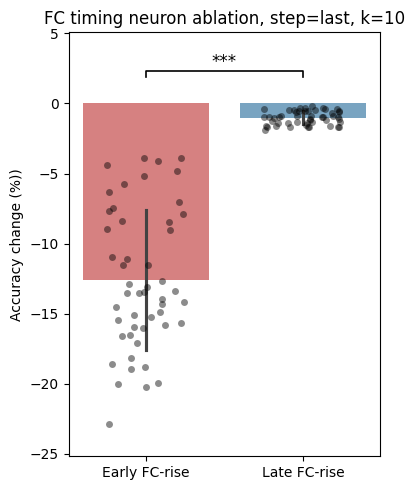

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

def get_significance_asterisks(p):
    """根据 p 值返回显著性标记"""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def plot_ablation_summary_with_sig(df, step_label, k):
    groups = ["Early FC-rise", "Late FC-rise"]
    
    plt.figure(figsize=(4, 5)) # 稍微增加高度以容纳显著性标记
    ax = sns.barplot(data=df, x="Group", y="Acc_Change", order=groups, palette=["tab:red", "tab:blue"], errorbar="sd", alpha=0.65)
    sns.stripplot(data=df, x="Group", y="Acc_Change", order=groups, color="black", alpha=0.45, jitter=0.25, size=5, ax=ax)
    # plt.axhline(0, color="black", linestyle="--")
    
    # 显著性检验配对: Early vs Late, Early vs Random, Late vs Random
    pairs = [(0, 1)]
    
    # 获取数据极值用于计算连线的高度位置
    y_max = df["Acc_Change"].max()
    y_range = df["Acc_Change"].max() - df["Acc_Change"].min()
    if y_range == 0:
        y_range = 1.0
        
    # 设置初始连线高度和间隔
    current_y = y_max + y_range * 0.08
    bracket_height = y_range * 0.02
    
    for (i, j) in pairs:
        data1 = df[df["Group"] == groups[i]]["Acc_Change"].dropna().values
        data2 = df[df["Group"] == groups[j]]["Acc_Change"].dropna().values
        
        # 进行 Welch t 检验 (不假设方差齐性)
        t_stat, p_val = ttest_ind(data1, data2, equal_var=False)
        sig_str = get_significance_asterisks(p_val)
        
        # 绘制连线框架 [ |￣￣￣| ]
        x1, x2 = i, j
        plt.plot([x1, x1, x2, x2], 
                 [current_y, current_y + bracket_height, current_y + bracket_height, current_y], 
                 lw=1.2, c='black')
        
        # 居中添加显著性文字
        plt.text((x1 + x2) * 0.5, current_y + bracket_height, sig_str, 
                 ha='center', va='bottom', color='black', fontsize=12)
        
        # 为下一组配对抬高水平线，避免重叠
        current_y += (bracket_height + y_range * 0.12)

    # 动态调整纵坐标上限，确保标记显示完整
    ax.set_ylim(bottom=df["Acc_Change"].min() - y_range * 0.1, top=current_y)

    plt.ylabel("Accuracy change (%))")
    plt.xlabel("")
    plt.title(f"FC timing neuron ablation, step={step_label}, k={k}")
    # plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(f"./fig/fc_timing_ablation_step_{step_label}_k_{k}.pdf", format='pdf')
    plt.show()

# 提取 last step 数据并重新绘图
step_key = "last"
if step_key in multi_step_results:
    last_step_data = multi_step_results[step_key]
    plot_ablation_summary_with_sig(
        df=last_step_data["ablation_df"], 
        step_label=step_key, 
        k=last_step_data["ablation_info"]["k"]
    )
else:
    print("未在 multi_step_results 中找到 'last' 步的结果。")

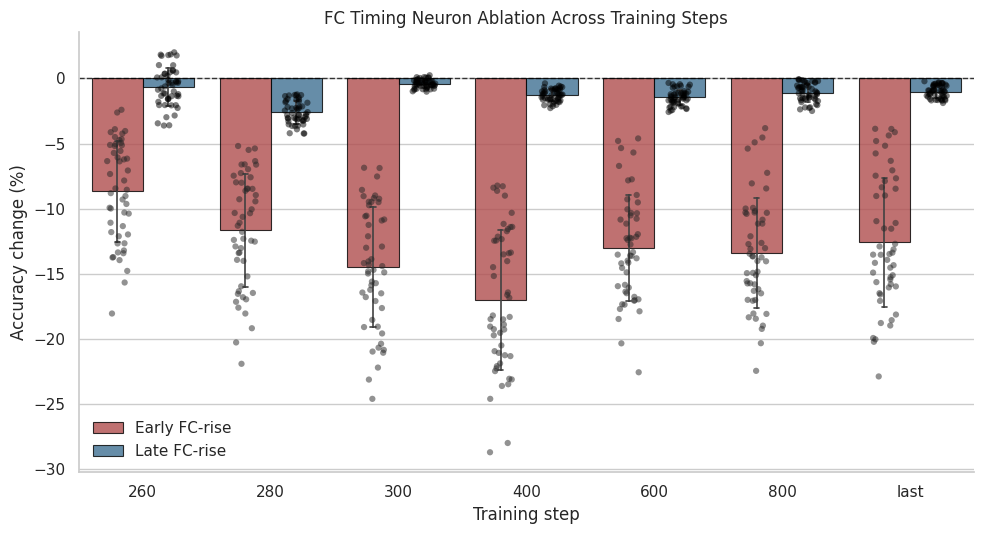

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_steps = [260, 280, 300, 400, 600, 800, "last"]
groups = ["Early FC-rise", "Late FC-rise"]
all_df = []

for step in target_steps:
    key = next((k for k in [step, str(step)] if k in multi_step_results), None)
    if key is None:
        print(f"跳过 step={step}：未找到结果")
        continue
    result = multi_step_results[key]
    if "ablation_df" not in result:
        print(f"跳过 step={step}：没有 ablation_df")
        continue
    df_step = result["ablation_df"].copy()
    df_step["Step"] = str(step)
    all_df.append(df_step)

if not all_df:
    raise ValueError("multi_step_results 中没有可绘制的 ablation_df")

plot_df = pd.concat(all_df, ignore_index=True)
plot_df = plot_df[plot_df["Group"].isin(groups)].copy()
step_order = [str(s) for s in target_steps if str(s) in plot_df["Step"].unique()]
plot_df["Step"] = pd.Categorical(plot_df["Step"], categories=step_order, ordered=True)

# sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.barplot(
    data=plot_df, x="Step", y="Acc_Change", hue="Group",
    order=step_order, hue_order=groups,
    palette=["#c03d3e", "#3274a1"],
    errorbar="sd", capsize=0.08, err_kws={"linewidth": 1.2},
    alpha=0.8, edgecolor="black", linewidth=0.8, ax=ax
)

sns.stripplot(
    data=plot_df, x="Step", y="Acc_Change", hue="Group",
    order=step_order, hue_order=groups,
    dodge=True, jitter=0.18, color="black",
    alpha=0.5, size=4.5, ax=ax, legend=False
)

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.75)
ax.set_xlabel("Training step")
ax.set_ylabel("Accuracy change (%)")
ax.set_title("FC Timing Neuron Ablation Across Training Steps")
ax.legend(title="", frameon=False, loc="best")
# ax.grid(axis="x", visible=False)
# ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("./fig/fc_timing_ablation_across_steps.pdf", format="pdf", bbox_inches="tight")
plt.show()

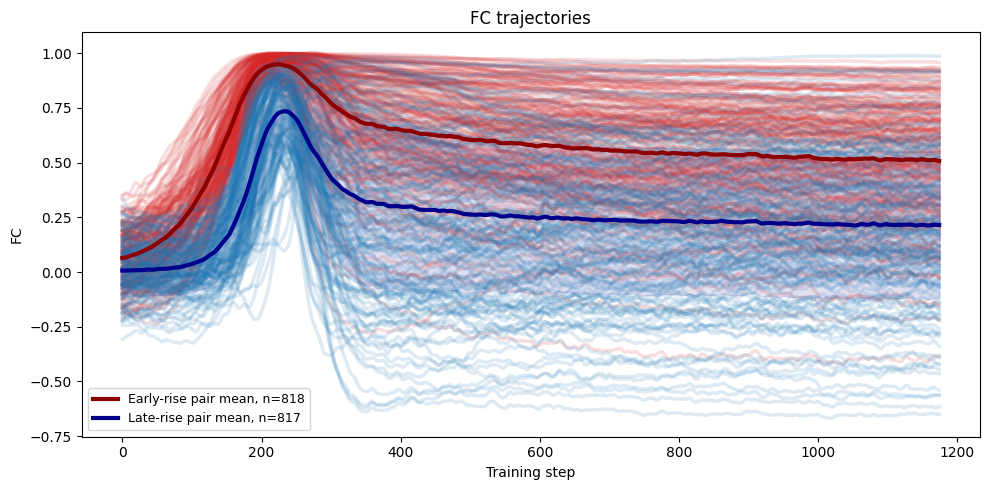


Selected pair full-training summary
Early pair final mean: 0.5070528883237634
Late pair final mean: 0.2143941942985143
Early pair final median: 0.554343454561281
Late pair final median: 0.22140095228522677
Mann Whitney test on final |FC|
U=497581.0, p=1.0297e-65


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from scipy.stats import mannwhitneyu

def plot_selected_pair_fc_full_training(
    fc_trajectories_abs,
    sampled_steps,
    fc_rise_result,
    num_pairs=120,
    smooth_sigma=3.0,
    seed=42
):
    rng = np.random.default_rng(seed)

    early_pairs = fc_rise_result["early_rise_pairs"]
    late_pairs = fc_rise_result["late_rise_pairs"]

    def sample_pairs(pairs):
        if len(pairs) <= num_pairs:
            return pairs
        idx = rng.choice(len(pairs), size=num_pairs, replace=False)
        return [pairs[i] for i in idx]

    early_show = sample_pairs(early_pairs)
    late_show = sample_pairs(late_pairs)

    early_trajs_all = []
    late_trajs_all = []

    for i, j in early_pairs:
        early_trajs_all.append(
            gaussian_filter1d(fc_trajectories_abs[:, i, j], sigma=smooth_sigma)
        )

    for i, j in late_pairs:
        late_trajs_all.append(
            gaussian_filter1d(fc_trajectories_abs[:, i, j], sigma=smooth_sigma)
        )

    early_trajs_all = np.asarray(early_trajs_all)
    late_trajs_all = np.asarray(late_trajs_all)

    plt.figure(figsize=(10, 5))

    for i, j in early_show:
        traj = gaussian_filter1d(fc_trajectories_abs[:, i, j], sigma=smooth_sigma)
        plt.plot(sampled_steps, traj, color="tab:red", alpha=0.15, linewidth=2.5)

    for i, j in late_show:
        traj = gaussian_filter1d(fc_trajectories_abs[:, i, j], sigma=smooth_sigma)
        plt.plot(sampled_steps, traj, color="tab:blue", alpha=0.15, linewidth=2.5)

    plt.plot(
        sampled_steps,
        early_trajs_all.mean(axis=0),
        color="darkred",
        linewidth=3,
        label=f"Early-rise pair mean, n={len(early_pairs)}"
    )

    plt.plot(
        sampled_steps,
        late_trajs_all.mean(axis=0),
        color="darkblue",
        linewidth=3,
        label=f"Late-rise pair mean, n={len(late_pairs)}"
    )

    plt.fill_between(
        sampled_steps,
        early_trajs_all.mean(axis=0) - early_trajs_all.std(axis=0),
        early_trajs_all.mean(axis=0) + early_trajs_all.std(axis=0),
        color="darkred",
        alpha=0.12
    )

    plt.fill_between(
        sampled_steps,
        late_trajs_all.mean(axis=0) - late_trajs_all.std(axis=0),
        late_trajs_all.mean(axis=0) + late_trajs_all.std(axis=0),
        color="darkblue",
        alpha=0.12
    )

    # plt.axvspan(
    #     fc_rise_result["pre_window"][0],
    #     fc_rise_result["pre_window"][1],
    #     color="gray",
    #     alpha=0.12,
    #     label="pre window"
    # )

    # plt.axvspan(
    #     fc_rise_result["rise_window"][0],
    #     fc_rise_result["rise_window"][1],
    #     color="gold",
    #     alpha=0.10,
    #     label="rise window"
    # )

    # plt.axvline(
    #     fc_rise_result["median_time"],
    #     color="black",
    #     linestyle=":",
    #     linewidth=2,
    #     label="early late split"
    # )

    # plt.axhline(
    #     fc_rise_result["low_thres"],
    #     color="gray",
    #     linestyle="--",
    #     linewidth=1
    # )

    # plt.axhline(
    #     fc_rise_result["high_thres"],
    #     color="black",
    #     linestyle="--",
    #     linewidth=1
    # )

    plt.xlabel("Training step")
    plt.ylabel("FC")
    plt.title("FC trajectories")
    plt.legend(frameon=True, fontsize=9)
    plt.tight_layout()
    # plt.savefig("./fig/fc_timing_selected_pairs_full_training.pdf", format='pdf')
    plt.show()

    print("")
    print("Selected pair full-training summary")
    print("Early pair final mean:", early_trajs_all[:, -1].mean())
    print("Late pair final mean:", late_trajs_all[:, -1].mean())
    print("Early pair final median:", np.median(early_trajs_all[:, -1]))
    print("Late pair final median:", np.median(late_trajs_all[:, -1]))

    u, p = mannwhitneyu(
        early_trajs_all[:, -1],
        late_trajs_all[:, -1],
        alternative="two-sided"
    )

    print("Mann Whitney test on final |FC|")
    print(f"U={u:.1f}, p={p:.4e}")

    return early_trajs_all, late_trajs_all

early_pair_curves_full, late_pair_curves_full = plot_selected_pair_fc_full_training(
    fc_trajectories_abs=fc_trajectories_raw,
    sampled_steps=sampled_steps,
    fc_rise_result=fc_rise_result,
    num_pairs=150,
    smooth_sigma=3.0,
    seed=0
)

Mann–Whitney U test: U=0.0, p=1.7948e-253
Mann–Whitney U test: U=450170.0, p=4.6036e-68
Training-mean FC Mann–Whitney U test: U=479154.0, p=1.3495e-95


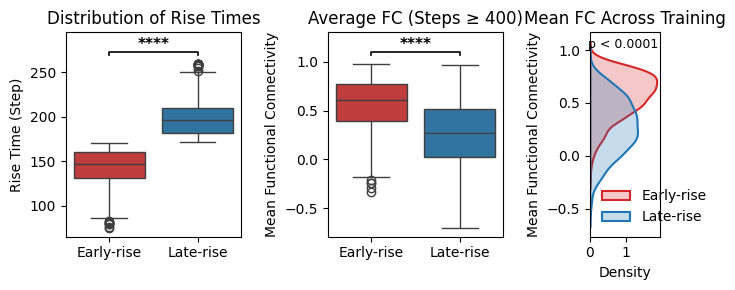

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def plot_fc_timing_violins(
    fc_trajectories_abs,
    sampled_steps,
    fc_rise_result,
    late_stage_step=400
):
    """
    绘制先上升和后上升神经元对的比较：
    1. 上升时间分布
    2. 后期（默认400步之后）平均FC分布
    3. 整个训练过程中平均FC的KDE分布
    """
    fc_trajectories_abs = np.asarray(fc_trajectories_abs)
    sampled_steps = np.asarray(sampled_steps)
    rise_times = np.asarray(fc_rise_result["rise_times"])
    median_time = fc_rise_result["median_time"]

    early_times = rise_times[rise_times <= median_time]
    late_times = rise_times[rise_times > median_time]

    df_time = pd.DataFrame({
        "Group": ["Early-rise"] * len(early_times) + ["Late-rise"] * len(late_times),
        "Value": np.concatenate([early_times, late_times])
    })

    late_stage_idx = np.where(sampled_steps >= late_stage_step)[0]
    if len(late_stage_idx) == 0:
        raise ValueError(f"未找到大于等于 {late_stage_step} 的采样步。")

    early_pairs = fc_rise_result["early_rise_pairs"]
    late_pairs = fc_rise_result["late_rise_pairs"]

    early_late_fc = np.asarray([
        fc_trajectories_abs[late_stage_idx, i, j].mean()
        for i, j in early_pairs
    ])
    late_late_fc = np.asarray([
        fc_trajectories_abs[late_stage_idx, i, j].mean()
        for i, j in late_pairs
    ])

    df_fc = pd.DataFrame({
        "Group": ["Early-rise"] * len(early_late_fc) + ["Late-rise"] * len(late_late_fc),
        "Value": np.concatenate([early_late_fc, late_late_fc])
    })

    early_training_mean_fc = np.asarray([
        fc_trajectories_abs[:, i, j].mean()
        for i, j in early_pairs
    ])
    late_training_mean_fc = np.asarray([
        fc_trajectories_abs[:, i, j].mean()
        for i, j in late_pairs
    ])

    def add_significance_marker(ax, data1, data2, x1=0, x2=1, y_offset=0.05):
        data1 = np.asarray(data1)
        data2 = np.asarray(data2)
        data1 = data1[np.isfinite(data1)]
        data2 = data2[np.isfinite(data2)]

        u, p = mannwhitneyu(data1, data2, alternative="two-sided")
        print(f"Mann–Whitney U test: U={u:.1f}, p={p:.4e}")

        if p < 0.0001:
            marker = "****"
        elif p < 0.001:
            marker = "***"
        elif p < 0.01:
            marker = "**"
        elif p < 0.05:
            marker = "*"
        else:
            marker = "ns"

        y_max = max(np.max(data1), np.max(data2))
        y_min = min(np.min(data1), np.min(data2))
        y_range = max(y_max - y_min, np.finfo(float).eps)
        y = y_max + y_range * y_offset
        h = y_range * 0.02

        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, color="black")
        ax.text((x1 + x2) / 2, y + h, marker, ha="center", va="bottom", fontsize=11, fontweight="bold")
        ax.set_ylim(top=y + h + y_range * 0.12)

        return u, p

    # fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    fig, axes = plt.subplots(
                                1, 3,
                                figsize=(7.2, 3),
                                gridspec_kw={"width_ratios": [1, 1, 0.4]}
                            )
    palette = {"Early-rise": "tab:red", "Late-rise": "tab:blue"}
    order = ["Early-rise", "Late-rise"]

    sns.boxplot(
        data=df_time, x="Group", y="Value", order=order,
        hue="Group", palette=palette, legend=False, ax=axes[0]
    )
    axes[0].set_title("Distribution of Rise Times")
    axes[0].set_ylabel("Rise Time (Step)")
    axes[0].set_xlabel("")
    add_significance_marker(axes[0], early_times, late_times)

    sns.boxplot(
        data=df_fc, x="Group", y="Value", order=order,
        hue="Group", palette=palette, legend=False, ax=axes[1]
    )
    axes[1].set_title(f"Average FC (Steps ≥ {late_stage_step})")
    axes[1].set_ylabel("Mean Functional Connectivity")
    axes[1].set_xlabel("")
    add_significance_marker(axes[1], early_late_fc, late_late_fc)

    sns.kdeplot(
        y=early_training_mean_fc, label="Early-rise",
        color=palette["Early-rise"], fill=True, alpha=0.25,
        linewidth=1.5, common_norm=False, ax=axes[2]
    )
    sns.kdeplot(
        y=late_training_mean_fc, label="Late-rise",
        color=palette["Late-rise"], fill=True, alpha=0.25,
        linewidth=1.5, common_norm=False, ax=axes[2]
    )
    axes[2].set_title("Mean FC Across Training")
    axes[2].set_xlabel("Density")
    axes[2].set_ylabel("Mean Functional Connectivity")
    axes[2].legend(frameon=False)

    u, p = mannwhitneyu(
        early_training_mean_fc,
        late_training_mean_fc,
        alternative="two-sided"
    )
    print(f"Training-mean FC Mann–Whitney U test: U={u:.1f}, p={p:.4e}")

    p_text = "p < 0.0001" if p < 0.0001 else f"p = {p:.4f}"
    axes[2].text(
        0.97, 0.97, p_text,
        transform=axes[2].transAxes,
        ha="right", va="top", fontsize=9
    )

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)

    plt.tight_layout()
    # plt.savefig("./fig/fc_timing_compare.pdf", format="pdf", bbox_inches="tight")
    plt.show()

plot_fc_timing_violins(
    fc_trajectories_abs=fc_trajectories_raw,
    sampled_steps=sampled_steps,
    fc_rise_result=fc_rise_result,
    late_stage_step=400
)

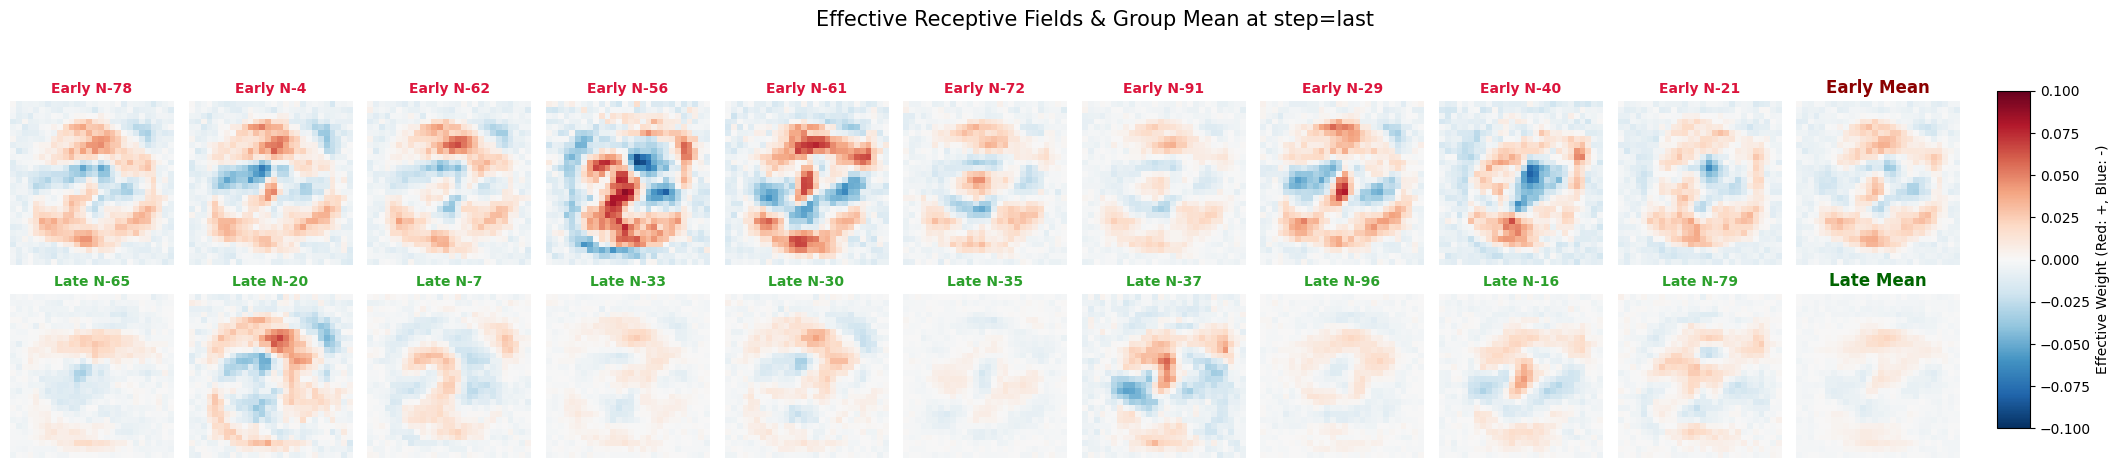

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def compute_effective_receptive_fields(model, layer_idx=1):
    """
    计算 MLP 中指定隐藏层神经元对原始输入的有效感受野（线性近似投影）
    返回 shape: [当前层神经元数量, 输入维度(如784)]
    """
    # 获取第一层的输入权重 (H0, Input_Dim)
    W_eff = model.linear_layers[0].weight.data.detach().cpu().numpy()
    
    # 逐层矩阵相乘，将深层权重投射回输入空间
    for l in range(1, layer_idx + 1):
        W_current = model.linear_layers[l].weight.data.detach().cpu().numpy()
        W_eff = np.dot(W_current, W_eff)
        
    return W_eff

def plot_neuron_receptive_fields_with_mean(
    model, 
    early_idx, 
    late_idx, 
    layer_idx=1, 
    input_shape=(28, 28), 
    n_show=10, 
    step_label="last"
):
    """
    对比绘制 Early 和 Late 组个体神经元的感受野，并在最后一列绘制组平均感受野
    """
    # 1. 计算投射回输入像素的权重矩阵
    W_eff = compute_effective_receptive_fields(model, layer_idx=layer_idx)
    
    # 2. 筛选我们要展示的神经元
    show_early = early_idx[:n_show] if len(early_idx) > n_show else early_idx
    show_late = late_idx[:n_show] if len(late_idx) > n_show else late_idx
    
    rf_early = W_eff[show_early]
    rf_late = W_eff[show_late]
    
    # 【新增逻辑】：计算各组的平均感受野
    rf_early_mean = rf_early.mean(axis=0)
    rf_late_mean = rf_late.mean(axis=0)
    
    # 3. 确定统一的颜色带（Colorbar）范围，加入均值的最大值以防万一
    max_val = max(
        np.max(np.abs(rf_early)), 
        np.max(np.abs(rf_late)),
        np.max(np.abs(rf_early_mean)),
        np.max(np.abs(rf_late_mean))
    )
    vmin, vmax = -0.1, 0.1
    
    # 4. 开始绘图：列数需要 +1，用于放平均值
    n_cols = max(len(show_early), len(show_late)) + 1
    fig, axes = plt.subplots(2, n_cols, figsize=(2 * n_cols, 4.5))
    
    # 如果 n_cols == 1 的情况保护 (极少发生)
    if n_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    # 绘制 Early 组个体
    for i, idx in enumerate(show_early):
        img = rf_early[i].reshape(input_shape)
        ax = axes[0, i]
        im = ax.imshow(img, cmap="RdBu_r", vmin=vmin, vmax=vmax)
        ax.set_title(f"Early N-{idx}", fontsize=10, color="crimson", fontweight="bold")
        ax.axis("off")
        
    # 【新增】：绘制 Early 组平均值 (放在第一行的最后一列)
    ax_early_mean = axes[0, -1]
    img_early_mean = rf_early_mean.reshape(input_shape)
    ax_early_mean.imshow(img_early_mean, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax_early_mean.set_title("Early Mean", fontsize=12, color="darkred", fontweight="black")
    ax_early_mean.axis("off")
    # 添加一个细边框突出显示均值图
    for spine in ax_early_mean.spines.values():
        spine.set_visible(True)
        spine.set_color('darkred')
        spine.set_linewidth(2)
        
    # 绘制 Late 组个体
    for i, idx in enumerate(show_late):
        img = rf_late[i].reshape(input_shape)
        ax = axes[1, i]
        im = ax.imshow(img, cmap="RdBu_r", vmin=vmin, vmax=vmax)
        ax.set_title(f"Late N-{idx}", fontsize=10, color="tab:green", fontweight="bold")
        ax.axis("off")
        
    # 【新增】：绘制 Late 组平均值 (放在第二行的最后一列)
    ax_late_mean = axes[1, -1]
    img_late_mean = rf_late_mean.reshape(input_shape)
    ax_late_mean.imshow(img_late_mean, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax_late_mean.set_title("Late Mean", fontsize=12, color="darkgreen", fontweight="black")
    ax_late_mean.axis("off")
    # 添加一个细边框突出显示均值图
    for spine in ax_late_mean.spines.values():
        spine.set_visible(True)
        spine.set_color('darkgreen')
        spine.set_linewidth(2)

    # 隐藏因为样本不足产生的空白子图（除最后一列外）
    for i in range(len(show_early), n_cols - 1):
        axes[0, i].axis("off")
    for i in range(len(show_late), n_cols - 1):
        axes[1, i].axis("off")
        
    # 添加整体标题和颜色条
    fig.suptitle(f"Effective Receptive Fields & Group Mean at step={step_label}", fontsize=15, y=1.05)
    
    # 调整颜色条位置，使其不会与最右侧的 Mean 图重叠
    cbar_ax = fig.add_axes([0.91, 0.12, 0.015, 0.75]) 
    fig.colorbar(im, cax=cbar_ax, label="Effective Weight (Red: +, Blue: -)")
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    # plt.savefig(f"./fig/receptive_fields_with_mean_step_{step_label}.pdf", format='pdf', bbox_inches='tight')
    plt.show()

# ----------------- 执行代码 -----------------
target_step = "last" 
vis_model, _, vis_label = build_checkpoint_model(
    models, target_step, input_size, hidden_dims, num_classes=10, act=act
)

plot_neuron_receptive_fields_with_mean(
    model=vis_model,
    early_idx=early_idx, 
    late_idx=late_idx,   
    layer_idx=1,         
    input_shape=(28, 28),
    n_show=10,           
    step_label=vis_label
)

Using step: 260
info_metrics shape: (5399, 20)
sample_group
Unaffected correct    2386
Early-only lost       2183
Both lost              481
Late-only lost         349

Model difficulty bins
Margin column: prob_margin
Hard cutoff: 0.03443491458892822
Easy cutoff: 0.03443491458892822
model_difficulty
easy    2700
hard    2699

Margin summary by sample group
                   prob_margin                                                               baseline_confidence                           true_class_prob                          
                          mean       std    median count      mean       std    median count                mean       std    median count            mean       std    median count
sample_group                                                                                                                                                                        
Both lost             0.015033  0.010759  0.013891   481  0.015033  0.010759  0.013891   481      

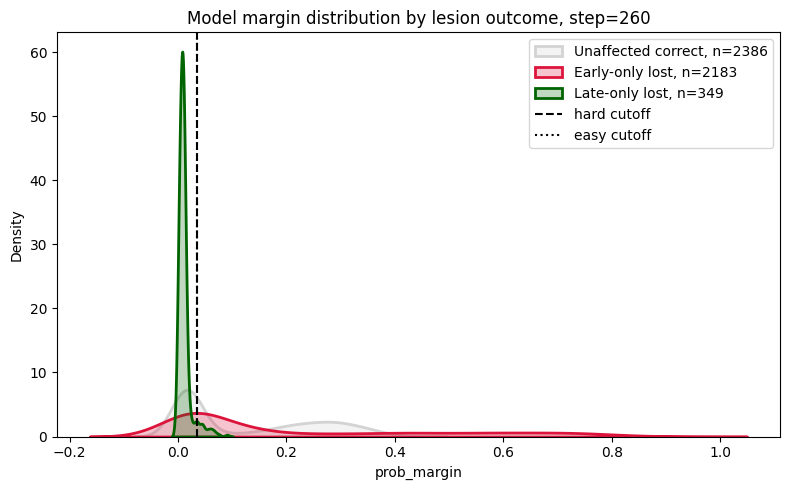

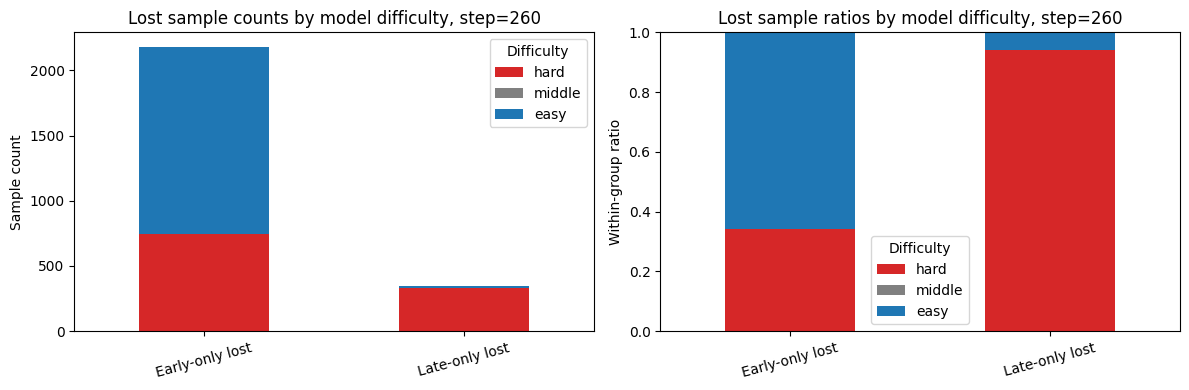

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def get_step_info_metrics(multi_step_results, target_step):
    key = str(target_step)
    if key not in multi_step_results:
        raise ValueError(f"Step {key} not found. Available steps: {list(multi_step_results.keys())}")
    info_metrics = multi_step_results[key]["info_metrics"].copy()
    print("Using step:", key)
    print("info_metrics shape:", info_metrics.shape)
    print(info_metrics["sample_group"].value_counts().to_string())
    return info_metrics

def add_model_difficulty_bins(
    info_metrics,
    margin_col="logit_margin",
    hard_q=0.25,
    easy_q=0.75
):
    df = info_metrics.copy()

    hard_cut = df[margin_col].quantile(hard_q)
    easy_cut = df[margin_col].quantile(easy_q)

    df["model_difficulty"] = "middle"
    df.loc[df[margin_col] <= hard_cut, "model_difficulty"] = "hard"
    df.loc[df[margin_col] >= easy_cut, "model_difficulty"] = "easy"

    print("")
    print("Model difficulty bins")
    print("Margin column:", margin_col)
    print("Hard cutoff:", hard_cut)
    print("Easy cutoff:", easy_cut)
    print(df["model_difficulty"].value_counts().to_string())

    return df, hard_cut, easy_cut

def summarize_lost_by_difficulty(df, margin_col="logit_margin"):
    groups = ["Unaffected correct", "Early-only lost", "Late-only lost", "Both lost"]
    use_df = df[df["sample_group"].isin(groups)].copy()

    print("")
    print("Margin summary by sample group")
    print(
        use_df.groupby("sample_group")[
            [margin_col, "prob_margin", "baseline_confidence", "true_class_prob"]
        ]
        .agg(["mean", "std", "median", "count"])
        .to_string()
    )

    print("")
    print("Difficulty bin counts")
    print(
        pd.crosstab(
            use_df["sample_group"],
            use_df["model_difficulty"]
        )
        .to_string()
    )

    print("")
    print("Difficulty bin ratio within each sample group")
    ratio = pd.crosstab(
        use_df["sample_group"],
        use_df["model_difficulty"],
        normalize="index"
    )
    print(ratio.to_string())

    lost_df = use_df[use_df["sample_group"].isin(["Early-only lost", "Late-only lost"])]

    x = lost_df[lost_df["sample_group"] == "Early-only lost"][margin_col].dropna().to_numpy()
    y = lost_df[lost_df["sample_group"] == "Late-only lost"][margin_col].dropna().to_numpy()

    if len(x) > 0 and len(y) > 0:
        u, p = mannwhitneyu(x, y, alternative="two-sided")
        print("")
        print(f"Mann Whitney test on {margin_col}")
        print(f"Early-only lost vs Late-only lost: U={u:.1f}, p={p:.4e}")

    return use_df

def plot_lost_margin_distributions(
    df,
    target_step,
    margin_col="logit_margin",
    hard_cut=None,
    easy_cut=None
):
    plot_groups = ["Unaffected correct", "Early-only lost", "Late-only lost"]
    plot_df = df[df["sample_group"].isin(plot_groups)].copy()

    palette = {
        "Unaffected correct": "lightgray",
        "Early-only lost": "crimson",
        "Late-only lost": "darkgreen"
    }

    plt.figure(figsize=(8, 5))

    for g in plot_groups:
        sub = plot_df[plot_df["sample_group"] == g]
        if len(sub) == 0:
            continue
        sns.kdeplot(
            data=sub,
            x=margin_col,
            fill=True,
            alpha=0.25,
            linewidth=2,
            color=palette[g],
            label=f"{g}, n={len(sub)}"
        )

    if hard_cut is not None:
        plt.axvline(
            hard_cut,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="hard cutoff"
        )

    if easy_cut is not None:
        plt.axvline(
            easy_cut,
            color="black",
            linestyle=":",
            linewidth=1.5,
            label="easy cutoff"
        )

    plt.xlabel(margin_col)
    plt.ylabel("Density")
    plt.title(f"Model margin distribution by lesion outcome, step={target_step}")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

def plot_lost_difficulty_composition(df, target_step):
    groups = ["Early-only lost", "Late-only lost"]
    order = ["hard", "middle", "easy"]

    lost_df = df[df["sample_group"].isin(groups)].copy()

    count_table = pd.crosstab(
        lost_df["sample_group"],
        lost_df["model_difficulty"]
    ).reindex(index=groups, columns=order, fill_value=0)

    ratio_table = pd.crosstab(
        lost_df["sample_group"],
        lost_df["model_difficulty"],
        normalize="index"
    ).reindex(index=groups, columns=order, fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    count_table.plot(
        kind="bar",
        stacked=True,
        color=["tab:red", "gray", "tab:blue"],
        ax=axes[0]
    )

    axes[0].set_title(f"Lost sample counts by model difficulty, step={target_step}")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Sample count")
    axes[0].tick_params(axis="x", rotation=15)
    axes[0].legend(title="Difficulty")

    ratio_table.plot(
        kind="bar",
        stacked=True,
        color=["tab:red", "gray", "tab:blue"],
        ax=axes[1]
    )

    axes[1].set_title(f"Lost sample ratios by model difficulty, step={target_step}")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Within-group ratio")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=15)
    axes[1].legend(title="Difficulty")

    plt.tight_layout()
    plt.show()

def plot_margin_box_by_lost_group(
    df,
    target_step,
    margin_col="logit_margin"
):
    plot_groups = ["Unaffected correct", "Early-only lost", "Late-only lost"]
    plot_df = df[df["sample_group"].isin(plot_groups)].copy()

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=plot_df,
        x="sample_group",
        y=margin_col,
        order=plot_groups,
        showfliers=False,
        palette=["lightgray", "crimson", "darkgreen"]
    )

    sns.stripplot(
        data=plot_df,
        x="sample_group",
        y=margin_col,
        order=plot_groups,
        color="black",
        alpha=0.18,
        size=2,
        jitter=0.2
    )

    plt.xlabel("")
    plt.ylabel(margin_col)
    plt.title(f"Model margin of different sample groups, step={target_step}")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

target_step = "260"

info_metrics_step = get_step_info_metrics(
    multi_step_results=multi_step_results,
    target_step=target_step
)

df_difficulty, hard_cut, easy_cut = add_model_difficulty_bins(
    info_metrics=info_metrics_step,
    margin_col="prob_margin",
    hard_q=0.5,
    easy_q=0.5
)

df_lost_difficulty = summarize_lost_by_difficulty(
    df=df_difficulty,
    margin_col="prob_margin"
)

plot_lost_margin_distributions(
    df=df_difficulty,
    target_step=target_step,
    margin_col="prob_margin",
    hard_cut=hard_cut,
    easy_cut=easy_cut
)

# plot_margin_box_by_lost_group(
#     df=df_difficulty,
#     target_step=target_step,
#     margin_col="logit_margin"
# )

plot_lost_difficulty_composition(
    df=df_difficulty,
    target_step=target_step
)

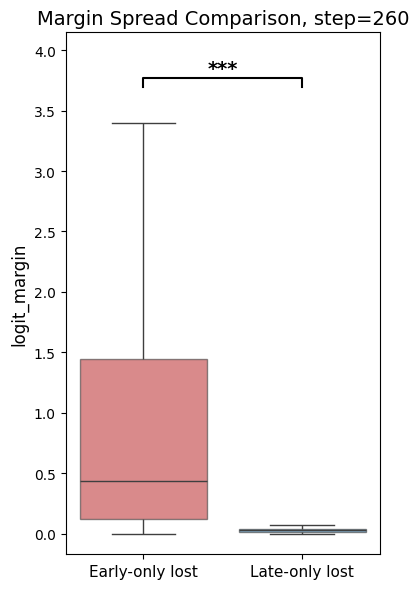

统计检验结果: U=684194.0, p-value=2.2008e-126


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def plot_margin_box_specific(df, target_step, margin_col="prob_margin"):
    # 只提取我们要对比的两组
    plot_groups = ["Early-only lost", "Late-only lost"]
    plot_df = df[df["sample_group"].isin(plot_groups)].copy()

    palette = {
        "Early-only lost": "tab:red",
        "Late-only lost": "tab:blue"
    }

    plt.figure(figsize=(4, 6))

    # 绘制箱线图
    ax = sns.boxplot(
        data=plot_df,
        x="sample_group",
        y=margin_col,
        order=plot_groups,
        showfliers=False, 
        palette=palette,
        boxprops={'alpha': 0.6} # 让箱体半透明，凸显散点
    )

    # ================= 新增：显著性计算与标记 =================
    
    # 1. 提取两组有效数据
    data_early = plot_df[plot_df["sample_group"] == "Early-only lost"][margin_col].dropna()
    data_late = plot_df[plot_df["sample_group"] == "Late-only lost"][margin_col].dropna()

    # 2. 进行 Mann-Whitney U 检验
    u, p = mannwhitneyu(data_early, data_late, alternative="two-sided")

    # 3. 确定星号级别
    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    # 4. 计算标记的 Y 轴高度（基于非离群点的最大值）
    def get_whisker_max(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        # 获取不超过上晶须界限的最大实际数据点
        return series[series <= q3 + 1.5 * iqr].max()

    max_y = max(get_whisker_max(data_early), get_whisker_max(data_late))
    
    # 获取当前 Y 轴范围用于计算合适的偏移比例
    y_min, y_max_current = ax.get_ylim()
    y_range = y_max_current - y_min
    
    # 设定连线的基础高度和两端向下折出的短线高度
    y_line = max_y + y_range * 0.08
    h = y_range * 0.02

    # 5. 在图中绘制折线和文字 (0 代表第一个箱子，1 代表第二个箱子)
    plt.plot([0, 0, 1, 1], [y_line, y_line+h, y_line+h, y_line], lw=1.5, color="black")
    plt.text(0.5, y_line+h, stars, ha="center", va="bottom", color="black", fontsize=14, fontweight="bold")

    # 6. 稍微抬高 Y 轴上限，防止显著性标记被图表边缘切掉
    ax.set_ylim(y_min, y_line + h + y_range * 0.1)
    # ==========================================================

    plt.xlabel("")
    plt.ylabel(margin_col, fontsize=12)
    plt.title(f"Margin Spread Comparison, step={target_step}", fontsize=14)
    plt.xticks(fontsize=11)
    
    plt.tight_layout()
    # plt.savefig(f"./fig/margin_box_specific_step_{target_step}.pdf", format='pdf', bbox_inches='tight')
    plt.show()

    print(f"统计检验结果: U={u:.1f}, p-value={p:.4e}")

# 调用示例
plot_margin_box_specific(
    df=df_difficulty,
    target_step=target_step,
    margin_col="logit_margin" # 或者 "entropy", "prob_margin"
)

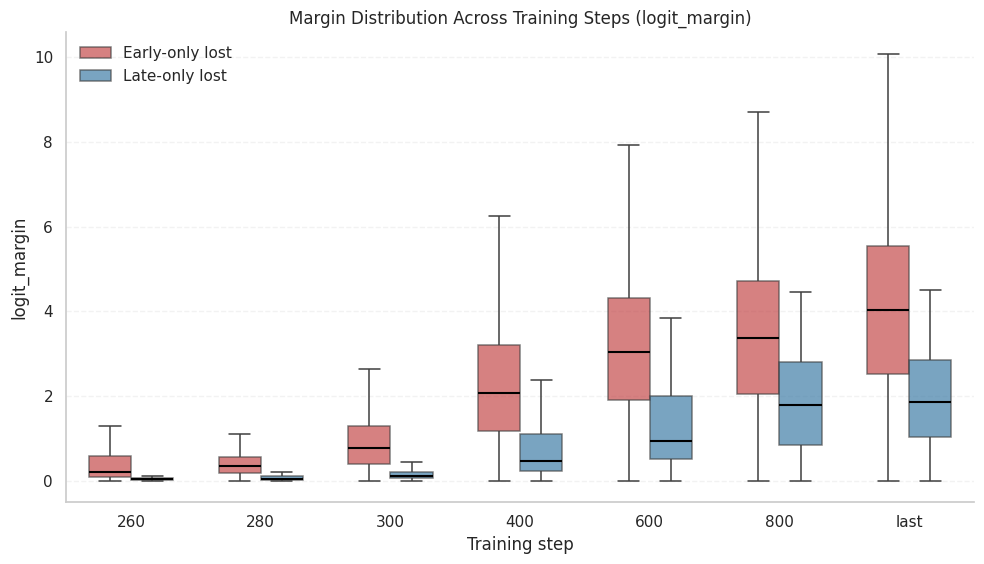

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_steps = [260, 280, 300, 400, 600, 800, "last"]
plot_groups = ["Early-only lost", "Late-only lost"]
margin_col = "logit_margin"  # 可改为 "prob_margin" 或 "entropy"
all_df = []

for step in target_steps:
    key = next((k for k in [step, str(step)] if k in multi_step_results), None)
    if key is None:
        print(f"跳过 step={step}：未找到结果")
        continue

    result = multi_step_results[key]

    # 根据实际保存位置提取 df_difficulty
    if "info_metrics" in result:
        df_step = result["info_metrics"].copy()
    elif "df_difficulty" in result:
        df_step = result["df_difficulty"].copy()
    else:
        print(f"跳过 step={step}：未找到 info_metrics 或 df_difficulty")
        continue

    if "sample_group" not in df_step.columns or margin_col not in df_step.columns:
        print(f"跳过 step={step}：缺少 sample_group 或 {margin_col}")
        continue

    df_step["Step"] = str(step)
    all_df.append(df_step)

if not all_df:
    raise ValueError("没有找到可用于绘图的数据")

plot_df = pd.concat(all_df, ignore_index=True)
plot_df = plot_df[plot_df["sample_group"].isin(plot_groups)].copy()
step_order = [str(s) for s in target_steps if str(s) in plot_df["Step"].unique()]
plot_df["Step"] = pd.Categorical(plot_df["Step"], categories=step_order, ordered=True)

sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(10, 5.8))

sns.boxplot(
    data=plot_df,
    x="Step",
    y=margin_col,
    hue="sample_group",
    order=step_order,
    hue_order=plot_groups,
    palette={"Early-only lost": "tab:red", "Late-only lost": "tab:blue"},
    showfliers=False,
    width=0.65,
    linewidth=1.1,
    boxprops={"alpha": 0.65},
    medianprops={"color": "black", "linewidth": 1.5},
    whiskerprops={"linewidth": 1.1},
    capprops={"linewidth": 1.1},
    ax=ax
)

ax.set_xlabel("Training step")
ax.set_ylabel(margin_col)
ax.set_title(f"Margin Distribution Across Training Steps ({margin_col})")
ax.legend(title="", frameon=False)
# ax.grid(axis="x", visible=False)
# ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
os.makedirs("./fig", exist_ok=True)
plt.savefig(f"./fig/margin_box_across_steps_{margin_col}.pdf", format="pdf", bbox_inches="tight")
plt.show()


Multi-step Difficulty Ratio:
Step           Group  Hard_Ratio  Easy_Ratio  Total_Count
 260 Early-only lost   43.130165   56.869835         1936
 260  Late-only lost   96.941176    3.058824          850
 280 Early-only lost   45.292331   54.707669         2634
 280  Late-only lost   90.404040    9.595960          594
 300 Early-only lost   43.830409   56.169591         3420
 300  Late-only lost   92.693111    7.306889          479
 400 Early-only lost   51.393817   48.606183         3946
 400  Late-only lost   95.681063    4.318937          301
 600 Early-only lost   52.996575   47.003425         3504
 600  Late-only lost   95.256917    4.743083          253
 800 Early-only lost   55.485299   44.514701         3163
 800  Late-only lost   95.049505    4.950495          202
last Early-only lost   53.929302   46.070698         3423
last  Late-only lost   99.074074    0.925926          216


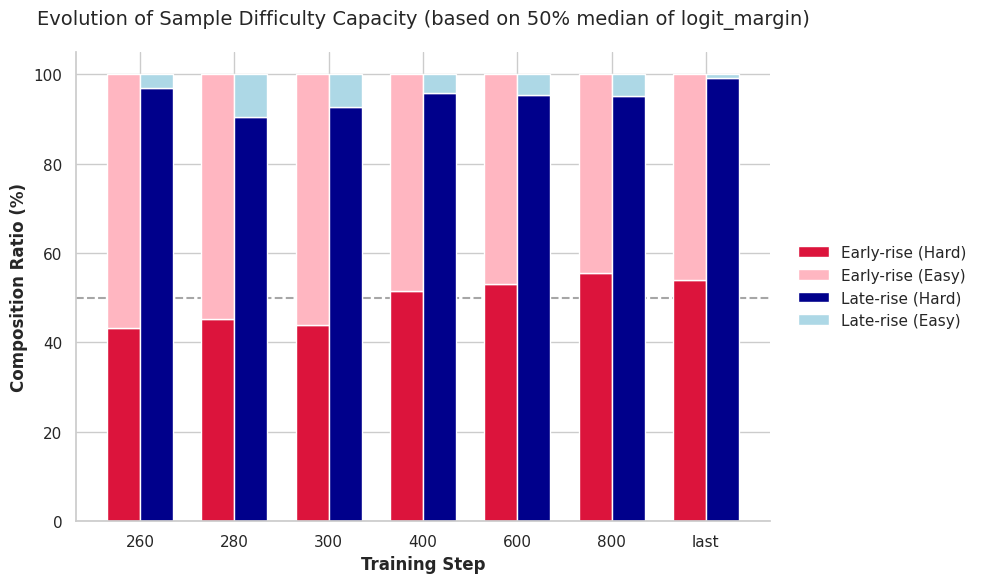

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_multi_step_difficulty_ratio(multi_step_results, margin_col="logit_margin"):
    """
    提取多步模型中，两组神经元各自丢失样本中 困难/简单 样本的比例。
    困难标准：当前步该指标的 50% 分位数（中位数）。
    """
    records = []
    
    # 提取并排序步骤 (确保 'last' 排在最后)
    steps = [s for s in multi_step_results.keys() if s != 'last']
    steps.sort(key=int)
    if 'last' in multi_step_results:
        steps.append('last')
        
    for step in steps:
        df = multi_step_results[step]["info_metrics"].copy()
        
        # 以全体样本的 50% 中位数作为简单/困难的分界线
        median_cut = df[margin_col].median()
        
        for group in ["Early-only lost", "Late-only lost"]:
            sub_df = df[df["sample_group"] == group]
            if len(sub_df) == 0:
                continue
                
            # logit_margin 越小越困难：小于等于中位数视为 Hard
            hard_count = (sub_df[margin_col] <= median_cut).sum()
            easy_count = (sub_df[margin_col] > median_cut).sum()
            total = hard_count + easy_count
            
            records.append({
                "Step": str(step),
                "Group": group,
                "Hard_Ratio": hard_count / total * 100,
                "Easy_Ratio": easy_count / total * 100,
                "Total_Count": total
            })
            
    return pd.DataFrame(records)


def plot_evolution_grouped_stacked_bars(df_ratio, margin_col="logit_margin"):
    """
    绘制随时间演变的分组百分百堆叠柱状图
    """
    # 确保步骤按原始顺序排列
    steps = df_ratio["Step"].unique()
    x = np.arange(len(steps))
    width = 0.35  # 柱子宽度
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 颜色定义 (深色代表Hard，浅色代表Easy)
    colors = {
        "Early_Hard": "crimson",
        "Early_Easy": "lightpink",
        "Late_Hard": "darkblue",
        "Late_Easy": "lightblue"
    }

    # 遍历每个步骤进行绘制
    for i, step in enumerate(steps):
        # 提取当前步两组的数据
        early_data = df_ratio[(df_ratio["Step"] == step) & (df_ratio["Group"] == "Early-only lost")]
        late_data = df_ratio[(df_ratio["Step"] == step) & (df_ratio["Group"] == "Late-only lost")]
        
        # 绘制早期组 (左侧柱子)
        if not early_data.empty:
            e_hard = early_data["Hard_Ratio"].values[0]
            e_easy = early_data["Easy_Ratio"].values[0]
            
            # 叠加柱：先画底层(Hard)，再画顶层(Easy)
            ax.bar(x[i] - width/2, e_hard, width, color=colors["Early_Hard"], edgecolor='white', linewidth=1)
            ax.bar(x[i] - width/2, e_easy, width, bottom=e_hard, color=colors["Early_Easy"], edgecolor='white', linewidth=1)
            
        # 绘制晚期组 (右侧柱子)
        if not late_data.empty:
            l_hard = late_data["Hard_Ratio"].values[0]
            l_easy = late_data["Easy_Ratio"].values[0]
            
            ax.bar(x[i] + width/2, l_hard, width, color=colors["Late_Hard"], edgecolor='white', linewidth=1)
            ax.bar(x[i] + width/2, l_easy, width, bottom=l_hard, color=colors["Late_Easy"], edgecolor='white', linewidth=1)

    # ---------------- 美化与图例设置 ----------------
    ax.set_ylabel("Composition Ratio (%)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Training Step", fontsize=12, fontweight='bold')
    ax.set_title(f"Evolution of Sample Difficulty Capacity (based on 50% median of {margin_col})", fontsize=14, pad=20)
    
    # 设置X轴标签
    ax.set_xticks(x)
    ax.set_xticklabels(steps, fontsize=11)
    
    # 画一条 50% 的基准线辅助视觉判断
    ax.axhline(50, color='gray', linestyle='--', alpha=0.7, linewidth=1.5, zorder=0)
    # ax.text(len(steps)-0.5, 51, 'Overall Median (50%)', color='gray', ha='right', va='bottom', fontsize=10)

    # 手动创建复杂的图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors["Early_Hard"], edgecolor='white', label='Early-rise (Hard)'),
        Patch(facecolor=colors["Early_Easy"], edgecolor='white', label='Early-rise (Easy)'),
        Patch(facecolor=colors["Late_Hard"], edgecolor='white', label='Late-rise (Hard)'),
        Patch(facecolor=colors["Late_Easy"], edgecolor='white', label='Late-rise (Easy)')
    ]
    
    # 将图例放在图表外部右侧
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11, frameon=False)
    
    # 隐藏上方和右侧的边框线
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    # plt.savefig("./fig/difficulty_evolution_stacked_bars.pdf", format='pdf', bbox_inches='tight')
    plt.show()

# ================= 运行执行 =================
# 1. 提取多步比例数据
df_ratio_evolution = extract_multi_step_difficulty_ratio(
    multi_step_results=multi_step_results, 
    margin_col="logit_margin"
)

# 2. 打印看看数据
print("\nMulti-step Difficulty Ratio:")
print(df_ratio_evolution.to_string(index=False))

# 3. 绘制进化图
plot_evolution_grouped_stacked_bars(
    df_ratio=df_ratio_evolution,
    margin_col="logit_margin"
)